# Notebook 2 — Obtención, Caracterización y Exploración de Datos
## Fuente: NIST Atomic Spectra Database (ASD)
## Proyecto: Óptica y Fotónica — Primer Parcial

**Estudiante:** Perez Criollo Andres David
**Formulario de líneas:** https://physics.nist.gov/PhysRefData/ASD/lines_form.html
**Formulario de niveles:** https://physics.nist.gov/PhysRefData/ASD/levels_form.html
**Endpoints:** `lines1.pl` (líneas espectrales) y `energy1.pl` (niveles de energía)

---

### Pregunta científica que orienta todo el análisis

> **¿Cómo se distribuyen las líneas espectrales de los primeros diez elementos de la tabla
> periódica (H a Ne) a lo largo del espectro electromagnético, y qué relación existe entre
> la probabilidad de transición espontánea (coeficiente de Einstein Aki) y la longitud de
> onda de emisión en cada elemento?**

De esta pregunta se desprende el criterio de prioridad que se usará durante todo el
diagnóstico:

| Prioridad | Variables | Razón |
|---|---|---|
| **Críticas** | longitud de onda, `Aki`, elemento/espectro, energías de nivel | Son las que responden directamente la pregunta |
| Secundarias | incertidumbres, referencias bibliográficas, *leading percentages*, factor de Landé | Documentan y enriquecen, pero su ausencia no impide responder |

---

### Alcance de este notebook

Este notebook cubre los puntos **2, 3 y el diagnóstico previo al 4** del enunciado:

1. **Obtención** de las dos fuentes desde la API oficial del NIST, guardando los archivos
   planos originales sin modificar.
2. **Caracterización** de cada fuente: qué columnas trae, qué tipo de dato tiene cada una,
   qué significa físicamente.
3. **Exploración y diagnóstico**: tipos incorrectos, valores faltantes, duplicados,
   inconsistencias, distribuciones, rangos y valores atípicos.
4. **Construcción del tercer dataset** (`df_analysis`) que une líneas y niveles.

**Lo que este notebook NO hace:** no limpia los datos. La limpieza se **justifica y se
ejecuta** en `notebooks/03_limpieza_datos.ipynb` (documentada en `docs/03_limpieza_datos.md`),
a partir de los hallazgos reales de este notebook.

**Lo que este notebook NO toca:** no crea bases de datos, no escribe en MySQL y no modifica
la infraestructura Docker. Todo el cómputo ocurre dentro del contenedor `jupyter`.

---

### Las dos fuentes son complementarias, no independientes

Cada **línea espectral** es el salto de un electrón entre dos **niveles de energía**: uno
inferior y uno superior. El archivo de líneas trae información parcial embebida de esos dos
niveles (configuración, término, energía), mientras que el archivo de niveles trae
información que el de líneas no tiene (incertidumbre del nivel, factor de Landé-g, leading
percentages, identificadores internos). Por eso en la Sección 11 se unen ambos.

---
# Sección 1 — Librerías y configuración del entorno

La imagen `quay.io/jupyter/scipy-notebook` ya incluye `pandas`, `numpy`, `matplotlib` y
`seaborn`. En lugar de un `!pip install` incondicional (que reinstala en cada ejecución y
no persiste al recrear el contenedor), se **verifica** qué hay y solo se instala lo que
falte.

In [1]:
# Verificacion de dependencias: solo se instala lo que realmente falte.
import importlib
import subprocess
import sys

REQUERIDAS = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "requests": "requests",
}

faltantes = []
for modulo, paquete in REQUERIDAS.items():
    try:
        importlib.import_module(modulo)
    except ImportError:
        faltantes.append(paquete)

if faltantes:
    print("Instalando paquetes faltantes:", faltantes)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltantes])
else:
    print("Todas las librerias necesarias ya estan disponibles en la imagen.")

Todas las librerias necesarias ya estan disponibles en la imagen.


In [2]:
import os
import re
import time
from datetime import datetime
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

%matplotlib inline

# Configuracion de visualizacion: que no se trunquen columnas al inspeccionar.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Versiones del entorno")
print("-" * 40)
print(f"Python     : {sys.version.split()[0]}")
print(f"pandas     : {pd.__version__}")
print(f"numpy      : {np.__version__}")
print(f"seaborn    : {sns.__version__}")
print(f"requests   : {requests.__version__}")
print()
print(f"Directorio de trabajo: {os.getcwd()}")
print(f"Ejecutado el         : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Versiones del entorno
----------------------------------------
Python     : 3.13.15
pandas     : 3.0.5
numpy      : 2.5.2
seaborn    : 0.13.2
requests   : 2.34.2

Directorio de trabajo: /home/jovyan/work
Ejecutado el         : 2026-09-19 19:06:01


---
# Sección 2 — Obtención de los datos

Se unifica aquí la descarga documentada en
`01_descarga_datos_iniciales.ipynb` (líneas y niveles), de modo que
este notebook sea **autocontenido**: se puede abrir y correr de arriba a abajo sin depender
de que otro notebook se haya ejecutado antes.

### Estrategia de caché

Descargar los niveles exige **18 peticiones** al NIST (el formulario de niveles solo acepta
un espectro por consulta) más 1 petición para las líneas: 19 en total. Volver a pedirlas en
cada ejecución sería lento y descortés con un servidor público.

Por eso se usa una caché en disco: si el archivo crudo ya existe en `datos_originales/`, se
lee de ahí; si no, se descarga y se guarda. El archivo guardado es **el texto crudo tal como
lo devolvió el NIST**, sin ninguna modificación, que es la evidencia de la fuente oficial
que exige la rúbrica.

Para forzar una descarga nueva basta con poner `FORZAR_DESCARGA = True`.

In [3]:
# ---------------------------------------------------------------------------
# Configuracion de rutas y de la politica de descarga
# ---------------------------------------------------------------------------

# Si es True, se ignora la cache y se vuelve a pedir todo al NIST.
FORZAR_DESCARGA = False

DIR_ORIGINALES = "datos_originales"
DIR_NIVELES = os.path.join(DIR_ORIGINALES, "niveles")

os.makedirs(DIR_ORIGINALES, exist_ok=True)
os.makedirs(DIR_NIVELES, exist_ok=True)

# Registro de procedencia: se va llenando con cada descarga para documentar el origen.
PROCEDENCIA = []


def obtener_csv_nist(url, parametros, ruta_cache, etiqueta, timeout=180):
    # Devuelve (texto_crudo, origen). Origen es 'cache' o 'red'.
    # Si el archivo ya existe y no se fuerza la descarga, se lee de disco.
    if os.path.exists(ruta_cache) and not FORZAR_DESCARGA:
        with open(ruta_cache, "r", encoding="utf-8") as f:
            texto = f.read()
        origen = "cache"
    else:
        respuesta = requests.get(url, params=parametros, timeout=timeout)
        respuesta.raise_for_status()
        texto = respuesta.text
        # Se guarda el texto EXACTO que devolvio el NIST, sin tocar nada.
        with open(ruta_cache, "w", encoding="utf-8") as f:
            f.write(texto)
        origen = "red"

    PROCEDENCIA.append({
        "fuente": etiqueta,
        "origen": origen,
        "archivo": ruta_cache,
        "bytes": os.path.getsize(ruta_cache),
        "momento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    })
    return texto, origen


def parsear_csv_nist(texto, nombre_espectro=None):
    # Convierte el texto CSV del NIST en DataFrame.
    # El NIST intercala lineas vacias y separadores de guiones que hay que descartar
    # ANTES de pasarle el texto a pandas.
    lineas = [ln for ln in texto.split("\n") if ln.strip() and not ln.startswith("---")]
    df = pd.read_csv(
        StringIO("\n".join(lineas)),
        sep=",",
        low_memory=False,
        on_bad_lines="warn",
    )
    # La cabecera del NIST termina en coma, asi que pandas inventa una columna
    # 'Unnamed: N' completamente vacia. No es un dato: es un artefacto del parseo.
    fantasmas = [c for c in df.columns
                 if str(c).startswith("Unnamed:") and df[c].isna().all()]
    if fantasmas:
        df = df.drop(columns=fantasmas)
    if nombre_espectro is not None:
        df.insert(0, "espectro", nombre_espectro)
    return df


print("Rutas listas:")
print(f"  {DIR_ORIGINALES}/")
print(f"  {DIR_NIVELES}/")
print(f"FORZAR_DESCARGA = {FORZAR_DESCARGA}")

Rutas listas:
  datos_originales/
  datos_originales/niveles/
FORZAR_DESCARGA = False


## 2.1 — Líneas espectrales (`lines1.pl`)

Los parámetros replican exactamente las opciones del formulario web. Se conserva la
documentación parámetro por parámetro del notebook 01, porque justificar **por qué** se pidió
cada campo es parte del entregable.

Se añade un intento de traer los **identificadores internos de nivel** (`show_level_ids`).
El formulario de líneas los ofrece y serían la clave de unión ideal con el archivo de
niveles (que ya los pide vía `show_level_id`). El notebook **no asume que funcionen**: la
Sección 11 verifica contra las columnas realmente devueltas y, si no llegaron, elige otra
estrategia de unión.

In [4]:
URL_LINES = "https://physics.nist.gov/cgi-bin/ASD/lines1.pl"

# Los 18 espectros: 10 elementos en estado neutro (I) y primer ionizado (II).
# El H no tiene H II porque al ionizarse queda sin electrones (no hay transiciones).
# El He II existe pero se mantiene el mismo conjunto definido en el notebook 01.
ESPECTRA_STR = ("H I;He I;Li I;Li II;Be I;Be II;B I;B II;C I;C II;"
                "N I;N II;O I;O II;F I;F II;Ne I;Ne II")

PARAMS_LINES = {
    "spectra": ESPECTRA_STR,   # que elementos y estados de ionizacion consultar

    "low_w": "",               # limite inferior de longitud de onda: vacio = sin limite
    "upp_w": "",               # limite superior de longitud de onda: vacio = sin limite

    "unit": 1,                 # 0=Angstrom  1=nanometro  2=micrometro
                               # nm es la unidad estandar en optica/fotonica y permite
                               # clasificar UV (<380), visible (380-780) e IR (>780)

    "format": 2,               # 0=HTML  1=ASCII  2=CSV  3=tab-delimited
    "line_out": 0,             # 0=todas las lineas (no se filtra nada desde el origen)
    "en_unit": 0,              # 0=cm-1  1=eV  2=Rydberg  (cm-1 es la unidad nativa NIST)
    "output": 0,               # 0=todo en una sola pagina  1=paginado

    "show_obs_wl": 1,          # longitud de onda OBSERVADA (medicion experimental real)
    "show_calc_wl": 1,         # longitud de onda RITZ (calculada de la diferencia de niveles)
    "unc_out": 1,              # incertidumbre de la longitud de onda
    "order_out": 0,            # 0=ordenar por longitud de onda
    "show_av": 2,              # convencion estandar NIST: vacio/aire segun el rango

    "A_out": 0,                # coeficiente de Einstein Aki (s^-1): el dato central
                               # para la pregunta cientifica de este proyecto
    "f_out": "on",             # fuerza de oscilador fik
    "loggf_out": "on",         # log(gf): el notebook 01 lo anunciaba pero no lo pedia
    "intens_out": "on",        # intensidad relativa de la linea
    "allowed_out": 1,          # incluir transiciones permitidas (E1)
    "forbid_out": 1,           # incluir transiciones prohibidas (M1, E2, ...)

    "conf_out": "on",          # configuracion electronica de cada nivel
    "term_out": "on",          # termino espectroscopico de cada nivel
    "enrg_out": "on",          # energia del nivel inferior y superior
    "J_out": "on",             # numero cuantico J (permite calcular g = 2J+1)
    "g_out": "on",             # degeneracion g de cada nivel
    "ids_out": 1,              # IDs internos de nivel (ID_i, ID_k): la clave de union
                               # con energy1.pl. El nombre correcto del parametro es
                               # 'ids_out'; cualquier otro produce "Unknown parameter".

    "bibrefs": 1,              # referencias bibliograficas (trazabilidad cientifica)

    # Parametros tecnicos del formulario
    "submit": "Retrieve Data",
    "de": 0,
    "plot_out": 0,
    "I_scale_type": 1,
    "page_size": 15,
    "tsb_value": 0,
    "min_str": "",
    "max_str": "",
    "max_low_enrg": "",
    "max_upp_enrg": "",
    "min_accur": "",
    "min_intens": "",
}

print(f"Espectros solicitados: {len(ESPECTRA_STR.split(';'))}")
print(ESPECTRA_STR.replace(";", "  |  "))

Espectros solicitados: 18
H I  |  He I  |  Li I  |  Li II  |  Be I  |  Be II  |  B I  |  B II  |  C I  |  C II  |  N I  |  N II  |  O I  |  O II  |  F I  |  F II  |  Ne I  |  Ne II


In [5]:
RUTA_LINES = os.path.join(DIR_ORIGINALES, "nist_lines_H_Ne_original.csv")

texto_lines, origen_lines = obtener_csv_nist(
    URL_LINES, PARAMS_LINES, RUTA_LINES, etiqueta="lineas espectrales"
)

print(f"Origen de los datos : {origen_lines}")
print(f"Archivo             : {RUTA_LINES}")
print(f"Tamano              : {os.path.getsize(RUTA_LINES):,} bytes")
print(f"Caracteres recibidos: {len(texto_lines):,}")
print(f"Lineas de texto     : {len(texto_lines.splitlines()):,}")

Origen de los datos : cache
Archivo             : datos_originales/nist_lines_H_Ne_original.csv
Tamano              : 5,418,514 bytes
Caracteres recibidos: 5,418,514
Lineas de texto     : 18,291


### Inspección del texto crudo *antes* de parsear

Este paso es parte de la caracterización, no un trámite. La exportación CSV del NIST suele
traer artefactos de formato (comillas, prefijos pensados para que Excel no reinterprete los
valores, separadores intercalados). Verlos **antes** de que `read_csv` los convierta en
columnas evita diagnosticar mal los tipos de dato más adelante: una columna que parece
"texto sucio" puede en realidad ser numérica envuelta en un artefacto de exportación.

In [6]:
lineas_crudas = texto_lines.splitlines()

print("=== Primeras 12 lineas LITERALES de la respuesta del NIST (lineas espectrales) ===")
for i, ln in enumerate(lineas_crudas[:12]):
    print(f"[{i:02d}] {ln[:220]}")

print()
print("=== Ultimas 3 lineas ===")
for i, ln in enumerate(lineas_crudas[-3:], start=len(lineas_crudas) - 3):
    print(f"[{i:02d}] {ln[:220]}")

=== Primeras 12 lineas LITERALES de la respuesta del NIST (lineas espectrales) ===
[00] element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1),fik,log_gf,Acc,Ei(cm-1),Ek(cm-1),conf_i,term_i,J_i,conf_k,term_k,J_k,g_i,g_k,Type,tp_ref,line_ref,ID_i,ID_k,
[01] C,2,"=""4.2767""","=""0.0004""","=""4.2766""","=""0.0004""","=""a*""","=""9.e+10""","=""2.3e-02""","=""-1.33""",D+,"=""0.000000""","=""2338290""","=""2s2.2p""","=""2P*""","=""1/2""","=""1s.2s2.2p2""","=""2S""","=""1/2"""
[02] C,2,"=""4.2767""","=""0.0004""","=""4.2767""","=""0.0004""","=""a*""","=""1.7e+11""","=""2.3e-02""","=""-1.03""",D+,"=""63.395090""","=""2338290""","=""2s2.2p""","=""2P*""","=""3/2""","=""1s.2s2.2p2""","=""2S""","=""1/2"
[03] C,2,"=""4.2836""","=""0.0004""","=""4.2836""","=""0.0004""","=""a*""","=""6.e+10""","=""2.3e-02""","=""-1.0""",E,"=""43024.9""","=""2377500""","=""2s.2p2""","=""4P""","=""3/2""","=""1s.2s.(3S). 2p3.(2P*)""","=""4P*""","=
[04] C,2,"=""4.2836""","=""0.0004""","=

In [7]:
df_lines_raw = parsear_csv_nist(texto_lines)

print("DataFrame de LINEAS ESPECTRALES cargado (tal cual salio del CSV).")
print(f"Filas   : {df_lines_raw.shape[0]:,}")
print(f"Columnas: {df_lines_raw.shape[1]}")
print()
print("Columnas devueltas por el NIST:")
for c in df_lines_raw.columns:
    print(f"  - {c}")
print()
print("Tipos detectados por pandas:")
print(df_lines_raw.dtypes.value_counts().to_string())

DataFrame de LINEAS ESPECTRALES cargado (tal cual salio del CSV).
Filas   : 18,290
Columnas: 26

Columnas devueltas por el NIST:
  - element
  - sp_num
  - obs_wl_vac(nm)
  - unc_obs_wl
  - ritz_wl_vac(nm)
  - unc_ritz_wl
  - intens
  - Aki(s^-1)
  - fik
  - log_gf
  - Acc
  - Ei(cm-1)
  - Ek(cm-1)
  - conf_i
  - term_i
  - J_i
  - conf_k
  - term_k
  - J_k
  - g_i
  - g_k
  - Type
  - tp_ref
  - line_ref
  - ID_i
  - ID_k

Tipos detectados por pandas:
str    26


## 2.2 — Niveles de energía (`energy1.pl`)

El formulario de niveles solo acepta **un espectro por petición**, así que se itera sobre
los 18 espectros. Cada respuesta cruda se guarda como archivo individual en
`datos_originales/niveles/` y al final se consolidan en un solo DataFrame, agregando una
columna `espectro` que permite distinguir a qué elemento pertenece cada nivel una vez
unidos.

Entre peticiones se deja una pausa de 1 segundo: es buena práctica al consumir una API
pública. La pausa solo se aplica cuando la descarga es real, no cuando se lee de caché.

In [8]:
URL_LEVELS = "https://physics.nist.gov/cgi-bin/ASD/energy1.pl"

ESPECTRA_LISTA = [
    "H I",   "He I",
    "Li I",  "Li II",
    "Be I",  "Be II",
    "B I",   "B II",
    "C I",   "C II",
    "N I",   "N II",
    "O I",   "O II",
    "F I",   "F II",
    "Ne I",  "Ne II",
]

PARAMS_LEVELS_BASE = {
    # "spectrum" se asigna dentro del bucle, uno por peticion

    "units": 1,              # 0=cm-1  1=eV  2=Rydberg  3=Hartree  4=GHz
                             # OJO: las lineas se pidieron en cm-1 (en_unit=0) y los
                             # niveles en eV. Esta diferencia de unidades se documenta
                             # como hallazgo y se resuelve por conversion en la Seccion 11,
                             # NO cambiando la descarga: cada unidad es la mas apropiada
                             # para su propio uso (cm-1 es nativa del NIST para lineas,
                             # eV es la mas interpretable para comparar niveles).

    "format": 2,             # CSV
    "output": 0,             # todo en una sola pagina
    "multiplet_ordered": 0,  # 0=ordenado por energia  1=ordenado por multiplete

    "conf_out": "on",        # configuracion electronica principal
    "term_out": "on",        # termino espectroscopico
    "level_out": "on",       # valor de la energia del nivel
    "unc_out": "on",         # incertidumbre de la energia del nivel
    "j_out": "on",           # numero cuantico J
    "g_out": "on",           # degeneracion estadistica g
    "ids_out": "on",         # identificador interno del nivel: LA CLAVE DE UNION
    "lande_out": "on",       # factor de Lande-g (respuesta a campos magneticos)
    "perc_out": "on",        # leading percentages (composicion de la funcion de onda)
    "biblio": "on",          # referencias bibliograficas

    "submit": "Retrieve Data",
    "page_size": 15,
    "temp": "",
    "de": 0,
}

print(f"Espectros a descargar uno por uno: {len(ESPECTRA_LISTA)}")

Espectros a descargar uno por uno: 18


In [9]:
lista_dfs = []
registro_descarga = []
textos_crudos_niveles = {}

print("Descargando niveles de energia...")
print("=" * 72)

for i, espectro in enumerate(ESPECTRA_LISTA, start=1):
    parametros = dict(PARAMS_LEVELS_BASE)
    parametros["spectrum"] = espectro

    nombre_archivo = f"nist_levels_{espectro.replace(' ', '_')}_original.csv"
    ruta = os.path.join(DIR_NIVELES, nombre_archivo)

    try:
        texto, origen = obtener_csv_nist(
            URL_LEVELS, parametros, ruta, etiqueta=f"niveles {espectro}", timeout=120
        )
        textos_crudos_niveles[espectro] = texto

        df_esp = parsear_csv_nist(texto, nombre_espectro=espectro)

        if len(df_esp) > 0:
            lista_dfs.append(df_esp)
            estado = "OK"
        else:
            estado = "VACIO"

        registro_descarga.append({
            "espectro": espectro,
            "estado": estado,
            "origen": origen,
            "niveles": len(df_esp),
            "columnas": df_esp.shape[1],
        })
        print(f"[{i:02d}/18] {espectro:<6} {estado:<6} ({origen})  {len(df_esp):>5} niveles")

        # Pausa solo si se golpeo la red de verdad.
        if origen == "red":
            time.sleep(1)

    except Exception as e:
        registro_descarga.append({
            "espectro": espectro, "estado": f"ERROR", "origen": "-",
            "niveles": 0, "columnas": 0,
        })
        print(f"[{i:02d}/18] {espectro:<6} ERROR: {e}")

print("=" * 72)
df_registro = pd.DataFrame(registro_descarga)
display(df_registro)
print(f"Espectros exitosos: {(df_registro['estado'] == 'OK').sum()}/{len(ESPECTRA_LISTA)}")

Descargando niveles de energia...
[01/18] H I    OK     (cache)    106 niveles
[02/18] He I   OK     (cache)    843 niveles


[03/18] Li I   OK     (cache)    182 niveles


[04/18] Li II  OK     (cache)    179 niveles
[05/18] Be I   OK     (cache)    219 niveles
[06/18] Be II  OK     (cache)    258 niveles
[07/18] B I    OK     (cache)    125 niveles


[08/18] B II   OK     (cache)    157 niveles


[09/18] C I    OK     (cache)    435 niveles
[10/18] C II   OK     (cache)    415 niveles
[11/18] N I    OK     (cache)    381 niveles
[12/18] N II   OK     (cache)    197 niveles
[13/18] O I    OK     (cache)    614 niveles


[14/18] O II   OK     (cache)    287 niveles
[15/18] F I    OK     (cache)    303 niveles


[16/18] F II   OK     (cache)    291 niveles
[17/18] Ne I   OK     (cache)    375 niveles
[18/18] Ne II  OK     (cache)    385 niveles


,espectro,estado,origen,niveles,columnas
0,H I,OK,cache,106,12
1,He I,OK,cache,843,11
2,Li I,OK,cache,182,11
3,Li II,OK,cache,179,11
4,Be I,OK,cache,219,11
5,Be II,OK,cache,258,12
6,B I,OK,cache,125,12
7,B II,OK,cache,157,12
8,C I,OK,cache,435,13
9,C II,OK,cache,415,13


Espectros exitosos: 18/18


In [10]:
# Inspeccion del texto crudo de UNA respuesta de niveles, por la misma razon
# que se hizo con las lineas: ver el formato real antes de confiar en el parseo.
espectro_muestra = "He I"
if espectro_muestra in textos_crudos_niveles:
    print(f"=== Primeras 10 lineas LITERALES de la respuesta del NIST ({espectro_muestra}) ===")
    for i, ln in enumerate(textos_crudos_niveles[espectro_muestra].splitlines()[:10]):
        print(f"[{i:02d}] {ln[:220]}")

=== Primeras 10 lineas LITERALES de la respuesta del NIST (He I) ===
[00] Configuration,Term,J,g,Prefix,Level (eV),Suffix,Uncertainty (eV),Level ID,Reference
[01] "=""1s2""","=""1S""","=""0""",1,"=""[""","=""0.00000000""","=""]""","=""0.00000015""","=""002001.000001""","=""L22715"""
[02] "=""1s.2s""","=""3S""","=""1""",3,"=""[""","=""19.819614525""","=""]""","=""0.000000005""","=""002001.000002""","=""L22715c200,L20736"""
[03] "=""1s.2s""","=""1S""","=""0""",1,"=""[""","=""20.615774823""","=""]""","=""0.000000008""","=""002001.000003""","=""L22715c200,L20736"""
[04] "=""1s.2p""","=""3P*""","=""2""",5,"=""[""","=""20.96408688908""","=""]""","=""0.000000003""","=""002001.000004""","=""L22715c200,L20736"""
[05] "=""1s.2p""","=""3P*""","=""1""",3,"=""[""","=""20.96409636464""","=""]""","=""0.000000003""","=""002001.000005""","=""L22715c200,L20736"""
[06] "=""1s.2p""","=""3P*""","=""0""",1,"=""[""","=""20.96421885051""","=""]""","=""0.000000003""","=""002001.000006""","=""L22715c200,L20736"

In [11]:
df_levels_raw = pd.concat(lista_dfs, ignore_index=True)

# Se guarda tambien el consolidado. Los archivos POR ESPECTRO en datos_originales/niveles/
# son la evidencia cruda e intacta; este consolidado es una conveniencia derivada de ellos.
RUTA_LEVELS = os.path.join(DIR_ORIGINALES, "nist_levels_todos_original.csv")
df_levels_raw.to_csv(RUTA_LEVELS, index=False, encoding="utf-8")

print("DataFrame de NIVELES DE ENERGIA consolidado.")
print(f"Filas   : {df_levels_raw.shape[0]:,}")
print(f"Columnas: {df_levels_raw.shape[1]}")
print(f"Archivo : {RUTA_LEVELS} ({os.path.getsize(RUTA_LEVELS):,} bytes)")
print()
print("Columnas devueltas por el NIST:")
for c in df_levels_raw.columns:
    print(f"  - {c}")
print()
# Cada espectro se pidio por separado: si alguno devuelve un conjunto de columnas
# distinto, pd.concat produce la UNION de columnas rellenando con NaN. Se verifica.
conjuntos = {frozenset(d.columns) for d in lista_dfs}
print(f"Conjuntos de columnas distintos entre los 18 espectros: {len(conjuntos)}")
if len(conjuntos) > 1:
    print("Los espectros NO devolvieron todos las mismas columnas.")
    for d, esp in zip(lista_dfs, [r['espectro'] for r in registro_descarga if r['estado'] == 'OK']):
        print(f"  {esp:<7} -> {d.shape[1]} columnas")

DataFrame de NIVELES DE ENERGIA consolidado.
Filas   : 5,752
Columnas: 13
Archivo : datos_originales/nist_levels_todos_original.csv (888,532 bytes)

Columnas devueltas por el NIST:
  - espectro
  - Configuration
  - Term
  - J
  - g
  - Prefix
  - Level (eV)
  - Suffix
  - Uncertainty (eV)
  - Leading percentages
  - Level ID
  - Reference
  - Lande

Conjuntos de columnas distintos entre los 18 espectros: 3
Los espectros NO devolvieron todos las mismas columnas.
  H I     -> 12 columnas
  He I    -> 11 columnas
  Li I    -> 11 columnas
  Li II   -> 11 columnas
  Be I    -> 11 columnas
  Be II   -> 12 columnas
  B I     -> 12 columnas
  B II    -> 12 columnas
  C I     -> 13 columnas
  C II    -> 13 columnas
  N I     -> 11 columnas
  N II    -> 11 columnas
  O I     -> 11 columnas
  O II    -> 11 columnas
  F I     -> 11 columnas
  F II    -> 11 columnas
  Ne I    -> 11 columnas
  Ne II   -> 12 columnas


## 2.3 — Decodificación del formato de exportación

**Este es el hallazgo más importante de toda la obtención de datos, y condiciona todo lo
que viene después.**

La inspección del texto crudo reveló que el NIST no exporta los valores en limpio, sino
**envueltos** en un artefacto pensado para que Excel no reinterprete los datos. Después de
que `pandas` parsea el CSV, un valor numérico no queda como `91.2323660` sino como el texto
literal `="91.2323660"`, y —crucialmente— **un dato ausente no queda como `NaN`, sino como
el texto `=""`**.

Esto tiene dos consecuencias graves si se ignora:

1. **Todas las columnas quedan como `object` (texto)**, incluidas longitud de onda y `Aki`.
   No se podría calcular ni una media.
2. **`isnull()` devolvería cero nulos en todo el dataset**, porque `=""` es una cadena de
   texto perfectamente válida, no un valor ausente. El análisis de faltantes daría un
   resultado falso y tranquilizador.

### ¿Decodificar es limpiar?

No. Conviene ser preciso, porque la distinción importa para el alcance de este notebook:

- **Decodificar** es deshacer el envoltorio del formato de exportación para recuperar el
  valor que el NIST realmente quiso transmitir. Es equivalente a descomprimir un archivo:
  no altera la información, la hace legible. `="91.23"` y `91.23` **son el mismo dato**.
- **Limpiar** es tomar decisiones sobre el contenido: imputar, descartar, corregir. Eso
  **no** se hace aquí.

Sin decodificar sería imposible diagnosticar nada. Por eso se hace ya, y se conservan los
DataFrames crudos (`df_lines_raw`, `df_levels_raw`) para poder demostrar el contraste en la
Sección 4.

In [12]:
def decodificar_exportacion(df):
    # Deshace el envoltorio ="valor" del CSV del NIST y convierte las cadenas vacias
    # resultantes en NaN, que es lo que realmente significan.
    # NO altera el contenido de los datos: solo el envoltorio del formato de exportacion.
    salida = df.copy()
    for col in salida.columns:
        # Solo se saltan las columnas que YA son numericas. Ojo: no basta comparar
        # contra 'object', porque pandas 3 asigna un dtype 'str' propio a las columnas
        # de texto y esa comparacion las excluiria por error, dejando el artefacto
        # intacto y el analisis de nulos completamente falseado.
        if pd.api.types.is_numeric_dtype(salida[col]):
            continue
        s = salida[col].astype(str)
        # Quitar el prefijo =" y la comilla final que el NIST agrega
        s = s.str.replace(r'^="', "", regex=True).str.replace(r'"$', "", regex=True)
        s = s.str.strip()
        # Una cadena vacia (o el literal 'nan' que deja astype(str)) significa AUSENTE
        s = s.replace({"": np.nan, "nan": np.nan, "None": np.nan})
        salida[col] = s
    return salida


df_lines = decodificar_exportacion(df_lines_raw)
df_levels = decodificar_exportacion(df_levels_raw)

print("=== Efecto de la decodificacion ===")
comparativa = []
for nombre, crudo, dec in [("LINEAS", df_lines_raw, df_lines),
                           ("NIVELES", df_levels_raw, df_levels)]:
    comparativa.append({
        "fuente": nombre,
        "filas": len(crudo),
        "nulos_ANTES": int(crudo.isna().sum().sum()),
        "nulos_DESPUES": int(dec.isna().sum().sum()),
        "%_celdas_vacias_real": round(dec.isna().sum().sum() / np.prod(dec.shape) * 100, 2),
    })
display(pd.DataFrame(comparativa))

print("La columna 'nulos_ANTES' es el resultado ENGANOSO: sin decodificar, el dataset")
print("parece no tener ningun valor ausente. 'nulos_DESPUES' es la realidad.")

=== Efecto de la decodificacion ===


,fuente,filas,nulos_ANTES,nulos_DESPUES,%_celdas_vacias_real
0,LINEAS,18290,23640,90149,18.96
1,NIVELES,5752,8825,23013,30.78


La columna 'nulos_ANTES' es el resultado ENGANOSO: sin decodificar, el dataset
parece no tener ningun valor ausente. 'nulos_DESPUES' es la realidad.


In [13]:
# Demostracion concreta del cambio, valor por valor, en una columna cualquiera.
col_demo = next((c for c in df_lines_raw.columns if "ritz" in str(c).lower()), df_lines_raw.columns[0])

demo = pd.DataFrame({
    "crudo (df_lines_raw)": df_lines_raw[col_demo].head(6).astype(str),
    "decodificado (df_lines)": df_lines[col_demo].head(6).astype(str),
})
print(f"Columna de ejemplo: {col_demo}")
display(demo)

Columna de ejemplo: ritz_wl_vac(nm)


,crudo (df_lines_raw),decodificado (df_lines)
0,"=""4.2766""",4.2766
1,"=""4.2767""",4.2767
2,"=""4.2836""",4.2836
3,"=""4.2836""",4.2836
4,"=""4.2836""",4.2836
5,"=""4.2836""",4.2836


## 2.4 — Registro de procedencia

Documentar de dónde salió cada archivo, cuándo y con qué tamaño es parte del requisito de
reproducibilidad: cualquier persona debe poder rastrear cada dato hasta su fuente oficial.

In [14]:
df_procedencia = pd.DataFrame(PROCEDENCIA)
print(f"Total de archivos registrados: {len(df_procedencia)}")
print(f"Descargados de la red : {(df_procedencia['origen'] == 'red').sum()}")
print(f"Leidos de cache       : {(df_procedencia['origen'] == 'cache').sum()}")
print(f"Bytes totales         : {df_procedencia['bytes'].sum():,}")
print()
display(df_procedencia)

Total de archivos registrados: 19
Descargados de la red : 0
Leidos de cache       : 19
Bytes totales         : 6,260,800



,fuente,origen,archivo,bytes,momento
0,lineas espectrales,cache,datos_originales/nist_lines_H_Ne_original.csv,5418514,2026-09-19 19:06:02
1,niveles H I,cache,datos_originales/niveles/nist_levels_H_I_original.csv,17109,2026-09-19 19:06:02
2,niveles He I,cache,datos_originales/niveles/nist_levels_He_I_original.csv,117943,2026-09-19 19:06:02
3,niveles Li I,cache,datos_originales/niveles/nist_levels_Li_I_original.csv,20872,2026-09-19 19:06:02
4,niveles Li II,cache,datos_originales/niveles/nist_levels_Li_II_original.csv,21537,2026-09-19 19:06:02
5,niveles Be I,cache,datos_originales/niveles/nist_levels_Be_I_original.csv,26688,2026-09-19 19:06:02
6,niveles Be II,cache,datos_originales/niveles/nist_levels_Be_II_original.csv,45896,2026-09-19 19:06:02
7,niveles B I,cache,datos_originales/niveles/nist_levels_B_I_original.csv,22046,2026-09-19 19:06:02
8,niveles B II,cache,datos_originales/niveles/nist_levels_B_II_original.csv,28327,2026-09-19 19:06:03
9,niveles C I,cache,datos_originales/niveles/nist_levels_C_I_original.csv,87753,2026-09-19 19:06:03


In [15]:
print("=== Estructura de archivos generada ===")
for raiz, carpetas, archivos in os.walk(DIR_ORIGINALES):
    nivel = raiz.replace(DIR_ORIGINALES, "").count(os.sep)
    print("  " * nivel + os.path.basename(raiz) + "/")
    for archivo in sorted(archivos):
        ruta = os.path.join(raiz, archivo)
        print("  " * (nivel + 1) + f"{archivo}  ({os.path.getsize(ruta):,} bytes)")

=== Estructura de archivos generada ===
datos_originales/
  nist_levels_todos_original.csv  (888,532 bytes)
  nist_lines_H_Ne_original.csv  (5,418,514 bytes)
  niveles/
    nist_levels_B_II_original.csv  (28,327 bytes)
    nist_levels_B_I_original.csv  (22,046 bytes)
    nist_levels_Be_II_original.csv  (45,896 bytes)
    nist_levels_Be_I_original.csv  (26,688 bytes)
    nist_levels_C_II_original.csv  (79,333 bytes)
    nist_levels_C_I_original.csv  (87,753 bytes)
    nist_levels_F_II_original.csv  (33,766 bytes)
    nist_levels_F_I_original.csv  (36,137 bytes)
    nist_levels_H_I_original.csv  (17,109 bytes)
    nist_levels_He_I_original.csv  (117,943 bytes)
    nist_levels_Li_II_original.csv  (21,537 bytes)
    nist_levels_Li_I_original.csv  (20,872 bytes)
    nist_levels_N_II_original.csv  (22,423 bytes)
    nist_levels_N_I_original.csv  (44,432 bytes)
    nist_levels_Ne_II_original.csv  (79,968 bytes)
    nist_levels_Ne_I_original.csv  (52,442 bytes)
    nist_levels_O_II_original.cs

---
# Sección 3 — Primera inspección de cada fuente por separado

Antes de unir nada, se revisa cada fuente de manera independiente. El objetivo es responder:
**¿de qué está hecho este dataset?** Esto corresponde al "paso 1" de la metodología de los
ejemplos de clase: conocer toda la información general del dataset antes de tocarlo.

Primero se definen unos ayudantes que se usarán durante todo el notebook. El más importante
es `buscar_columna`: los nombres exactos de las columnas del NIST dependen de los parámetros
de la consulta, así que en lugar de escribirlos a mano (lo que rompería el notebook si el
NIST cambia una etiqueta) se **localizan por patrón** y se imprime el mapeo encontrado.

In [16]:
# ---------------------------------------------------------------------------
# Ayudantes reutilizados en todo el notebook
# ---------------------------------------------------------------------------

def quitar_artefacto(serie):
    # El NIST exporta algunos valores envueltos como ="valor" para que Excel no los
    # reinterprete. Esto NO es limpieza de datos: es deshacer un artefacto del formato
    # de exportacion para poder diagnosticar el contenido real de la columna.
    # IMPORTANTE: astype(str) convierte los NaN en la cadena 'nan'. Si no se
    # restaurasen, dos registros AUSENTES en fuentes distintas se emparejarian entre si
    # al construir claves de union, inflando falsamente la tasa de coincidencia.
    s = (
        serie.astype(str)
        .str.strip()
        .str.replace(r'^=', "", regex=True)
        .str.replace(r'^"|"$', "", regex=True)
        .str.strip()
    )
    return s.mask(serie.isna())


def normalizar_texto(serie):
    # Normalizacion usada SOLO para construir claves de union comparables:
    # colapsa espacios multiples, quita bordes y unifica a minusculas.
    s = (
        quitar_artefacto(serie)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .str.lower()
    )
    # Una cadena vacia no identifica nada: no puede servir de clave.
    return s.replace("", np.nan)


def buscar_columna(df, patrones):
    # Devuelve el nombre de la primera columna cuyo nombre case con alguno de los patrones.
    for patron in patrones:
        for col in df.columns:
            if re.search(patron, str(col), re.IGNORECASE):
                return col
    return None


def resumen_columnas(df, nombre):
    # Diccionario de datos generado a partir del DataFrame real.
    filas = []
    total = len(df)
    for col in df.columns:
        s = df[col]
        no_nulos = int(s.notna().sum())
        ejemplos = s.dropna().astype(str).head(3).tolist()
        filas.append({
            "columna": col,
            "dtype": str(s.dtype),
            "no_nulos": no_nulos,
            "nulos": total - no_nulos,
            "%_nulos": round((total - no_nulos) / total * 100, 2) if total else 0.0,
            "unicos": int(s.nunique(dropna=True)),
            "ejemplos": " | ".join(e[:28] for e in ejemplos),
        })
    out = pd.DataFrame(filas)
    print(f"=== Diccionario de datos: {nombre}  ({total:,} filas x {df.shape[1]} columnas) ===")
    return out


print("Ayudantes definidos.")

Ayudantes definidos.


## 3.1 — Líneas espectrales: forma y contenido

In [17]:
print(f"Dimensiones (filas, columnas): {df_lines.shape}")
print()
print("--- Primeras 5 filas ---")
display(df_lines.head())

Dimensiones (filas, columnas): (18290, 26)

--- Primeras 5 filas ---


,element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1),fik,log_gf,Acc,Ei(cm-1),Ek(cm-1),conf_i,term_i,J_i,conf_k,term_k,J_k,g_i,g_k,Type,tp_ref,line_ref,ID_i,ID_k
0,C,2,4.2767,0.0004,4.2766,0.0004,a*,9.e+10,2.3e-02,-1.33,D+,0.000000,2338290,2s2.2p,2P*,1/2,1s.2s2.2p2,2S,1/2,2,2,NaN,T9848LS,L20274,006002.000001,006002.000359
1,C,2,4.2767,0.0004,4.2767,0.0004,a*,1.7e+11,2.3e-02,-1.03,D+,63.395090,2338290,2s2.2p,2P*,3/2,1s.2s2.2p2,2S,1/2,4,2,NaN,T9848LS,L20274,006002.000002,006002.000359
2,C,2,4.2836,0.0004,4.2836,0.0004,a*,6.e+10,2.3e-02,-1.0,E,43024.9,2377500,2s.2p2,4P,3/2,1s.2s.(3S). 2p3.(2P*),4P*,5/2,4,6,NaN,T9848LS,L20274,006002.000004,006002.000367
3,C,2,4.2836,0.0004,4.2836,0.0004,a*,2.5e+10,7.e-03,-1.6,E,43024.9,2377500,2s.2p2,4P,3/2,1s.2s.(3S). 2p3.(2P*),4P*,3/2,4,4,NaN,T9848LS,L20274,006002.000004,006002.000366
4,C,2,4.2836,0.0004,4.2836,0.0004,a*,1.5e+11,2.1e-02,-1.1,E,43024.9,2377500,2s.2p2,4P,3/2,1s.2s.(3S). 2p3.(2P*),4P*,1/2,4,2,NaN,T9848LS,L20274,006002.000004,006002.000365


In [18]:
print("--- Ultimas 5 filas ---")
display(df_lines.tail())
print()
print("--- Muestra aleatoria de 5 filas ---")
display(df_lines.sample(5, random_state=42))

--- Ultimas 5 filas ---


,element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1),fik,log_gf,Acc,Ei(cm-1),Ek(cm-1),conf_i,term_i,J_i,conf_k,term_k,J_k,g_i,g_k,Type,tp_ref,line_ref,ID_i,ID_k
18285,H,1,25590000000.0,30000000.0,25640000000,30000000,NaN,NaN,NaN,NaN,NaN,[108324.72016],[108324.72055],9p,2P*,1/2,9s,2S,1/2,2,2,NaN,NaN,L15291c33,001001.001.000038,001001.001.000039
18286,H,1,35100000000.0,50000000.0,34480000000,50000000,NaN,NaN,NaN,NaN,NaN,[108581.99051],[108581.99080],10p,2P*,1/2,10s,2S,1/2,2,2,NaN,NaN,L15291c33,001001.001.000043,001001.001.000044
18287,H,1,46710000000.0,70000000.0,45450000000,60000000,NaN,NaN,NaN,NaN,NaN,[108772.34135],[108772.34157],11p,2P*,1/2,11s,2S,1/2,2,2,NaN,NaN,L15291c33,001001.001.000048,001001.001.000049
18288,H,1,55000000000.0,9000000000.0,56000000000,6000000000,NaN,NaN,NaN,NaN,NaN,97492.319433,97492.319611,3d,2D,3/2,3p,2P*,3/2,4,4,NaN,NaN,L4386,001001.001.000007,001001.001.000008
18289,H,1,60640000000.0,90000000.0,62500000000,90000000,NaN,NaN,NaN,NaN,NaN,[108917.11870],[108917.11886],12p,2P*,1/2,12s,2S,1/2,2,2,NaN,NaN,L15291c33,001001.001.000053,001001.001.000054



--- Muestra aleatoria de 5 filas ---


,element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1),fik,log_gf,Acc,Ei(cm-1),Ek(cm-1),conf_i,term_i,J_i,conf_k,term_k,J_k,g_i,g_k,Type,tp_ref,line_ref,ID_i,ID_k
10424,F,1,817.9339,0.0002,817.934+,NaN,600,6.0e+06,6.1e-02,-0.44,C,115917.91,128140.48,2s2.2p4.(3P).3p,4P*,5/2,2s2.2p4.(3P).3d,2D,5/2,6,6,NaN,T7043,L7481,009001.000008,009001.000031
14018,He,1,NaN,NaN,1943.788583,0.000010,NaN,3.4865e+02,1.9760e-05,-3.85912,AAA,[191451.871342758],[196595.059597060],1s.4f,3F*,3,1s.8d,3D,3,7,7,NaN,T8636c73,NaN,002001.000027,002001.000103
13694,Ne,1,1838.91674,0.00020,1838.9165,0.0005,480,NaN,NaN,NaN,NaN,162410.1736,167846.6738,2s2.2p5.(2P*<1/2>).3d,2[5/2]*,3,2s2.2p5.(2P*<1/2>).4f,2[5/2],3,7,7,NaN,NaN,L9097,010001.000029,010001.000073
10525,He,1,NaN,NaN,836.173561,0.000006,2*,3.8126e+05,3.9986e-03,-1.92097,AAA,[183236.789095],[195192.7429528],1s.3s,3S,1,1s.6p,3P*,1,3,3,NaN,T8636c73,L366,002001.000008,002001.000053
7975,Be,2,466.374,0.06,466.37,0.06,*,NaN,NaN,NaN,NaN,1081700+x,1103136+x,1s.2p.3d,4P*,1/2,1s.2p.4f,4D,3/2,2,4,NaN,NaN,L12158,004002.000157,004002.000202


In [19]:
print("=== info() de LINEAS ESPECTRALES ===")
df_lines.info()

=== info() de LINEAS ESPECTRALES ===
<class 'pandas.DataFrame'>
RangeIndex: 18290 entries, 0 to 18289
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   element          18290 non-null  str  
 1   sp_num           18290 non-null  str  
 2   obs_wl_vac(nm)   9866 non-null   str  
 3   unc_obs_wl       7692 non-null   str  
 4   ritz_wl_vac(nm)  18108 non-null  str  
 5   unc_ritz_wl      13270 non-null  str  
 6   intens           9881 non-null   str  
 7   Aki(s^-1)        12605 non-null  str  
 8   fik              12605 non-null  str  
 9   log_gf           12605 non-null  str  
 10  Acc              12605 non-null  str  
 11  Ei(cm-1)         18075 non-null  str  
 12  Ek(cm-1)         18075 non-null  str  
 13  conf_i           18075 non-null  str  
 14  term_i           17857 non-null  str  
 15  J_i              17857 non-null  str  
 16  conf_k           18075 non-null  str  
 17  term_k           17814 n

In [20]:
dic_lines = resumen_columnas(df_lines, "LINEAS ESPECTRALES")
display(dic_lines)

=== Diccionario de datos: LINEAS ESPECTRALES  (18,290 filas x 26 columnas) ===


,columna,dtype,no_nulos,nulos,%_nulos,unicos,ejemplos
0,element,str,18290,0,0.00,11,C | C | C
1,sp_num,str,18290,0,0.00,3,2 | 2 | 2
2,obs_wl_vac(nm),str,9866,8424,46.06,8017,4.2767 | 4.2767 | 4.2836
3,unc_obs_wl,str,7692,10598,57.94,164,0.0004 | 0.0004 | 0.0004
4,ritz_wl_vac(nm),str,18108,182,1.00,16647,4.2766 | 4.2767 | 4.2836
5,unc_ritz_wl,str,13270,5020,27.45,289,0.0004 | 0.0004 | 0.0004
6,intens,str,9881,8409,45.98,1345,a* | a* | a*
7,Aki(s^-1),str,12605,5685,31.08,7162,9.e+10 | 1.7e+11 | 6.e+10
8,fik,str,12605,5685,31.08,6865,2.3e-02 | 2.3e-02 | 2.3e-02
9,log_gf,str,12605,5685,31.08,7018,-1.33 | -1.03 | -1.0


## 3.2 — Niveles de energía: forma y contenido

In [21]:
print(f"Dimensiones (filas, columnas): {df_levels.shape}")
print()
print("--- Primeras 5 filas ---")
display(df_levels.head())
print()
print("--- Muestra aleatoria de 5 filas ---")
display(df_levels.sample(5, random_state=42))

Dimensiones (filas, columnas): (5752, 13)

--- Primeras 5 filas ---


,espectro,Configuration,Term,J,g,Prefix,Level (eV),Suffix,Uncertainty (eV),Leading percentages,Level ID,Reference,Lande
0,H I,1s,2S,1/2,2.0,NaN,0.00000000000000,NaN,0.00000000000012,100,001001.001.000001,NaN,NaN
1,H I,2p,2P*,1/2,2.0,NaN,10.19880615024,NaN,0.00000000004,100,001001.001.000002,L15291,NaN
2,H I,2p,2P*,3/2,4.0,NaN,10.19885151459,NaN,0.00000000005,100,001001.001.000004,L15291,NaN
3,H I,2s,2S,1/2,2.0,NaN,10.19881052514816,NaN,0.00000000000012,100,001001.001.000003,L15291,NaN
4,H I,2,NaN,NaN,8.0,NaN,10.1988358,NaN,0.0000012,100,001001.001.000059,L15291,NaN



--- Muestra aleatoria de 5 filas ---


,espectro,Configuration,Term,J,g,Prefix,Level (eV),Suffix,Uncertainty (eV),Leading percentages,Level ID,Reference,Lande
2471,C I,C II (2s2.2p 2P*<3/2>),Limit,---,NaN,NaN,11.2681480,NaN,0.0000011,NaN,006001.Lim002,L20057,NaN
5243,Ne I,2s2.2p5.(2P*<3/2>).9d,2[1/2]*,1,3.0,NaN,21.395449,NaN,0.000006,NaN,010001.000251,L8826,NaN
3406,N II,2s2.2p.(2P*<3/2>).5f,2[7/2],4,9.0,NaN,27.429262,NaN,NaN,NaN,007002.000120,NaN,NaN
4213,O II,2s2.2p2.(1D).3d,2S,1/2,2.0,NaN,31.693188,NaN,NaN,NaN,008002.000110,NaN,NaN
3076,N I,2s2.2p2.(3P<2>).5f,2[2]*,5/2,6.0,[,14.004979,],NaN,NaN,007001.000169,NaN,NaN


In [22]:
print("=== info() de NIVELES DE ENERGIA ===")
df_levels.info()

=== info() de NIVELES DE ENERGIA ===
<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   espectro             5752 non-null   str    
 1   Configuration        5751 non-null   str    
 2   Term                 5711 non-null   str    
 3   J                    5704 non-null   str    
 4   g                    5700 non-null   float64
 5   Prefix               1220 non-null   str    
 6   Level (eV)           5689 non-null   str    
 7   Suffix               1494 non-null   str    
 8   Uncertainty (eV)     3689 non-null   str    
 9   Leading percentages  1761 non-null   str    
 10  Level ID             5752 non-null   str    
 11  Reference            3511 non-null   str    
 12  Lande                29 non-null     str    
dtypes: float64(1), str(12)
memory usage: 940.3 KB


In [23]:
dic_levels = resumen_columnas(df_levels, "NIVELES DE ENERGIA")
display(dic_levels)

=== Diccionario de datos: NIVELES DE ENERGIA  (5,752 filas x 13 columnas) ===


,columna,dtype,no_nulos,nulos,%_nulos,unicos,ejemplos
0,espectro,str,5752,0,0.00,18,H I | H I | H I
1,Configuration,str,5751,1,0.02,1399,1s | 2p | 2p
2,Term,str,5711,41,0.71,94,2S | 2P* | 2P*
3,J,str,5704,48,0.83,26,1/2 | 1/2 | 3/2
4,g,float64,5700,52,0.90,60,2.0 | 2.0 | 4.0
5,Prefix,str,1220,4532,78.79,2,[ | [ | (
6,Level (eV),str,5689,63,1.10,4795,0.00000000000000 | 10.19880615024 | 10.19885151459
7,Suffix,str,1494,4258,74.03,14,] | ] | )
8,Uncertainty (eV),str,3689,2063,35.87,210,0.00000000000012 | 0.00000000004 | 0.00000000005
9,Leading percentages,str,1761,3991,69.38,659,100 | 100 | 100


=== Cantidad de niveles de energia por espectro ===


,espectro,num_niveles
9,He I,843
16,O I,614
4,C I,435
5,C II,415
15,Ne II,385
12,N I,381
14,Ne I,375
6,F I,303
7,F II,291
17,O II,287


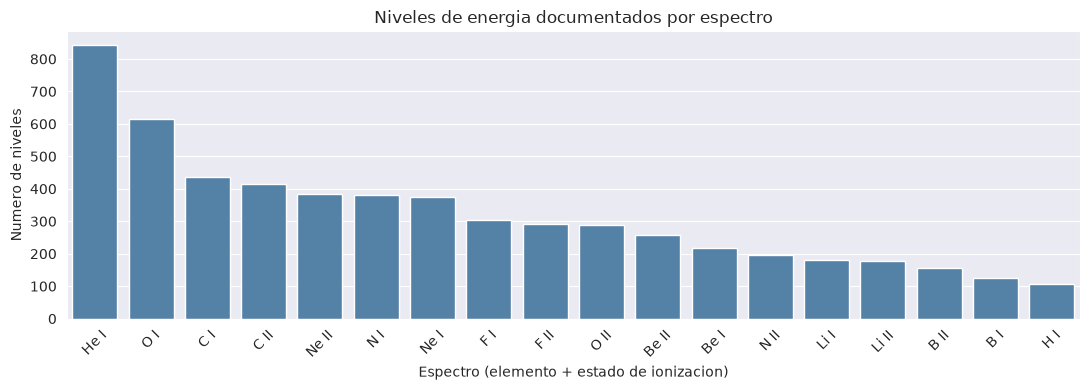

In [24]:
print("=== Cantidad de niveles de energia por espectro ===")
conteo_niveles = (
    df_levels.groupby("espectro").size()
    .reset_index(name="num_niveles")
    .sort_values("num_niveles", ascending=False)
)
display(conteo_niveles)

plt.figure(figsize=(11, 4))
sns.barplot(data=conteo_niveles, x="espectro", y="num_niveles", color="steelblue")
plt.title("Niveles de energia documentados por espectro")
plt.xlabel("Espectro (elemento + estado de ionizacion)")
plt.ylabel("Numero de niveles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.3 — Mapeo semántico de columnas

Se localizan las columnas clave por patrón y se imprime el resultado. Este mapeo es el que
usan todas las secciones siguientes, de modo que si el NIST devuelve una etiqueta distinta
a la esperada, el problema se ve **aquí**, explícito, en vez de reventar 20 celdas después.

In [25]:
COL_L = {
    "elemento":  buscar_columna(df_lines, [r"^element$", r"element"]),
    "sp_num":    buscar_columna(df_lines, [r"sp_num", r"spectrum"]),
    "wl_obs":    buscar_columna(df_lines, [r"obs_wl", r"observed.*wavelength"]),
    "wl_ritz":   buscar_columna(df_lines, [r"ritz_wl", r"ritz.*wavelength"]),
    "intens":    buscar_columna(df_lines, [r"^intens", r"intensity"]),
    "aki":       buscar_columna(df_lines, [r"^Aki", r"\bAki\b"]),
    "fik":       buscar_columna(df_lines, [r"^fik", r"\bfik\b"]),
    "loggf":     buscar_columna(df_lines, [r"log.*gf", r"gf"]),
    "acc":       buscar_columna(df_lines, [r"^Acc", r"accuracy"]),
    "Ei":        buscar_columna(df_lines, [r"^Ei", r"Ei\("]),
    "Ek":        buscar_columna(df_lines, [r"^Ek", r"Ek\("]),
    "conf_i":    buscar_columna(df_lines, [r"conf_i", r"lower.*conf"]),
    "term_i":    buscar_columna(df_lines, [r"term_i", r"lower.*term"]),
    "J_i":       buscar_columna(df_lines, [r"^J_i$", r"J_i"]),
    "g_i":       buscar_columna(df_lines, [r"^g_i$", r"g_i"]),
    "conf_k":    buscar_columna(df_lines, [r"conf_k", r"upper.*conf"]),
    "term_k":    buscar_columna(df_lines, [r"term_k", r"upper.*term"]),
    "J_k":       buscar_columna(df_lines, [r"^J_k$", r"J_k"]),
    "g_k":       buscar_columna(df_lines, [r"^g_k$", r"g_k"]),
    "tipo":      buscar_columna(df_lines, [r"^type$", r"tp_.*type"]),
    "id_i":      buscar_columna(df_lines, [r"lower.*level.*id", r"^i_id", r"id_i"]),
    "id_k":      buscar_columna(df_lines, [r"upper.*level.*id", r"^k_id", r"id_k"]),
}

COL_N = {
    "espectro":  "espectro",
    "conf":      buscar_columna(df_levels, [r"^Configuration$", r"configuration", r"^conf"]),
    "term":      buscar_columna(df_levels, [r"^Term$", r"term"]),
    "J":         buscar_columna(df_levels, [r"^J$", r"^J\b"]),
    "g":         buscar_columna(df_levels, [r"^g$", r"^g\b"]),
    "nivel":     buscar_columna(df_levels, [r"Level.*eV", r"^Level"]),
    "unc":       buscar_columna(df_levels, [r"Uncertainty"]),
    "lande":     buscar_columna(df_levels, [r"Land", r"lande"]),
    "perc":      buscar_columna(df_levels, [r"percent", r"Leading"]),
    "ref":       buscar_columna(df_levels, [r"Reference"]),
    "level_id":  buscar_columna(df_levels, [r"Level.*ID", r"level_id", r"^ID$"]),
}

print("=== Mapeo de columnas en LINEAS ESPECTRALES ===")
for k, v in COL_L.items():
    marca = "OK " if v else "NO "
    print(f"  [{marca}] {k:<10} -> {v}")

print()
print("=== Mapeo de columnas en NIVELES DE ENERGIA ===")
for k, v in COL_N.items():
    marca = "OK " if v else "NO "
    print(f"  [{marca}] {k:<10} -> {v}")

faltan_l = [k for k, v in COL_L.items() if v is None]
faltan_n = [k for k, v in COL_N.items() if v is None]
print()
print(f"Campos NO encontrados en lineas : {faltan_l}")
print(f"Campos NO encontrados en niveles: {faltan_n}")

=== Mapeo de columnas en LINEAS ESPECTRALES ===
  [OK ] elemento   -> element
  [OK ] sp_num     -> sp_num
  [OK ] wl_obs     -> obs_wl_vac(nm)
  [OK ] wl_ritz    -> ritz_wl_vac(nm)
  [OK ] intens     -> intens
  [OK ] aki        -> Aki(s^-1)
  [OK ] fik        -> fik
  [OK ] loggf      -> log_gf
  [OK ] acc        -> Acc
  [OK ] Ei         -> Ei(cm-1)
  [OK ] Ek         -> Ek(cm-1)
  [OK ] conf_i     -> conf_i
  [OK ] term_i     -> term_i
  [OK ] J_i        -> J_i
  [OK ] g_i        -> g_i
  [OK ] conf_k     -> conf_k
  [OK ] term_k     -> term_k
  [OK ] J_k        -> J_k
  [OK ] g_k        -> g_k
  [OK ] tipo       -> Type
  [OK ] id_i       -> ID_i
  [OK ] id_k       -> ID_k

=== Mapeo de columnas en NIVELES DE ENERGIA ===
  [OK ] espectro   -> espectro
  [OK ] conf       -> Configuration
  [OK ] term       -> Term
  [OK ] J          -> J
  [OK ] g          -> g
  [OK ] nivel      -> Level (eV)
  [OK ] unc        -> Uncertainty (eV)
  [OK ] lande      -> Lande
  [OK ] perc       -> 

In [26]:
# El archivo de niveles trae la columna 'espectro' (la agregamos al consolidar), pero el
# de lineas identifica el espectro con dos columnas: el simbolo del elemento y el estado
# de ionizacion como numero. Se reconstruye la misma etiqueta para poder cruzar ambas
# fuentes y agrupar por elemento.
ROMANOS = {1: "I", 2: "II", 3: "III", 4: "IV", 5: "V"}


def construir_espectro(df, col_elem, col_sp):
    elem = quitar_artefacto(df[col_elem]).str.strip()
    sp = pd.to_numeric(quitar_artefacto(df[col_sp]), errors="coerce")
    rom = sp.map(lambda v: ROMANOS.get(int(v), str(v)) if pd.notna(v) else None)
    return elem + " " + rom


df_lines["espectro"] = construir_espectro(df_lines, COL_L["elemento"], COL_L["sp_num"])

print("Columna 'espectro' reconstruida en el dataset de lineas.")
print(f"Espectros distintos en lineas : {df_lines['espectro'].nunique()}")
print(f"Espectros distintos en niveles: {df_levels['espectro'].nunique()}")
print()
comunes = set(df_lines["espectro"].dropna()) & set(df_levels["espectro"].dropna())
print(f"Espectros presentes en AMBAS fuentes: {len(comunes)}")
print(f"  Solo en lineas : {sorted(set(df_lines['espectro'].dropna()) - comunes)}")
print(f"  Solo en niveles: {sorted(set(df_levels['espectro'].dropna()) - comunes)}")

Columna 'espectro' reconstruida en el dataset de lineas.
Espectros distintos en lineas : 18
Espectros distintos en niveles: 18

Espectros presentes en AMBAS fuentes: 18
  Solo en lineas : []
  Solo en niveles: []


### Significado físico de las columnas

Interpretación de lo que devolvió el NIST, necesaria para poder decidir después qué se puede
imputar y qué no:

**Líneas espectrales** — cada fila es una **transición electrónica**:

| Columna | Significado | Rol frente a la pregunta científica |
|---|---|---|
| `element`, `sp_num` | Elemento químico y estado de ionización (1 = neutro, 2 = una vez ionizado) | **Crítica** — es la variable de agrupación |
| `obs_wl_*(nm)` | Longitud de onda **medida** en laboratorio | **Crítica** — eje X de la pregunta |
| `ritz_wl_*(nm)` | Longitud de onda **calculada** a partir de la diferencia de niveles | **Crítica** — respaldo cuando no hay medición |
| `unc_obs_wl`, `unc_ritz_wl` | Incertidumbre de cada longitud de onda | Secundaria — mide calidad del dato |
| `intens` | Intensidad relativa (brillo) de la línea | Secundaria — escala arbitraria por espectro |
| `Aki(s^-1)` | **Coeficiente de Einstein**: probabilidad de emisión espontánea | **Crítica** — eje Y de la pregunta |
| `Acc` | Código de exactitud del NIST para `Aki` (AAA, AA, A+, A, B+, B, C, D, E) | Secundaria — categórica ordinal |
| `Ei`, `Ek` (cm⁻¹) | Energía del nivel **inferior** y **superior** de la transición | **Crítica** — define la física del salto |
| `conf_i/term_i/J_i` | Identidad cuántica del nivel inferior | **Crítica** — clave de unión con niveles |
| `conf_k/term_k/J_k` | Identidad cuántica del nivel superior | **Crítica** — clave de unión con niveles |
| `Type` | Tipo de transición: vacío = permitida (E1); `M1`, `E2`… = prohibida | Importante — explica valores extremos de `Aki` |
| `tp_ref`, `line_ref` | Referencias bibliográficas | Secundaria — trazabilidad |

**Niveles de energía** — cada fila es un **estado cuántico** del átomo:

| Columna | Significado | Rol |
|---|---|---|
| `espectro` | Añadida por nosotros al consolidar: a qué elemento/ion pertenece el nivel | **Crítica** — sin ella los 18 archivos serían indistinguibles |
| `Configuration` | Configuración electrónica (ej. `1s2.2s2.2p`) | **Crítica** — clave de unión |
| `Term` | Término espectroscópico (ej. `2P*`, `3D`) | **Crítica** — clave de unión |
| `J` | Momento angular total | **Crítica** — clave de unión y base de `g = 2J+1` |
| `g` | Degeneración estadística del nivel | Importante |
| `Level (eV)` | Energía del nivel **en eV** (las líneas la traen en cm⁻¹) | **Crítica** — requiere conversión para cruzar |
| `Uncertainty (eV)` | Incertidumbre de la energía | Secundaria |
| `Landé-g` | Respuesta del nivel a un campo magnético (efecto Zeeman) | Secundaria |
| `Leading percentages` | Composición de la función de onda en niveles mezclados | Secundaria |
| `Reference` | Fuente bibliográfica del nivel | Secundaria |

---
# Sección 4 — Verificación de tipos de dato contra el contenido real

El tipo que `pandas` asigna automáticamente **no siempre es el correcto**. En los ejemplos
de clase, la columna `User_Score` aparecía como `object` porque contenía el texto `tbd` entre
los números; ese único valor arruinaba toda la columna.

Aquí se hace lo mismo pero de forma sistemática: para cada columna se intenta la conversión
a número **en seco** (sin asignar nada) y se cuenta cuántos valores se perderían. Además se
distingue entre dos causas distintas de fallo:

- **Artefacto de formato**: el valor es numérico pero viene envuelto (`="123"`). Es un
  problema de exportación, trivial de resolver.
- **Contenido realmente no numérico**: símbolos del NIST que marcan datos dudosos o
  estimados. Esos sí exigen una decisión de limpieza justificada.

Se muestran los **valores ofensivos reales**, no solo el conteo, porque saber *qué* texto
rompe la columna es lo que permite decidir después si se descarta, se convierte o se
reinterpreta.

In [27]:
def diagnostico_tipos(df, df_crudo, nombre):
    # Intento de conversion a numerico EN SECO (no se asigna nada).
    # Se compara contra el DataFrame crudo para dimensionar el efecto del artefacto.
    filas = []
    for col in df.columns:
        s = df[col]
        crudo_num = int(pd.to_numeric(df_crudo[col], errors="coerce").notna().sum()) \
            if col in df_crudo.columns else 0

        if pd.api.types.is_numeric_dtype(s):
            filas.append({
                "columna": col, "dtype": str(s.dtype), "no_nulos": int(s.notna().sum()),
                "numericos_en_crudo": crudo_num,
                "numericos_decodificado": int(s.notna().sum()),
                "irrecuperables": 0, "%_irrecuperable": 0.0, "veredicto": "ya numerica",
            })
            continue

        no_nulos = int(s.notna().sum())
        if no_nulos == 0:
            filas.append({
                "columna": col, "dtype": str(s.dtype), "no_nulos": 0,
                "numericos_en_crudo": crudo_num, "numericos_decodificado": 0,
                "irrecuperables": 0, "%_irrecuperable": 0.0, "veredicto": "columna vacia",
            })
            continue

        convertibles = int(pd.to_numeric(s, errors="coerce").notna().sum())
        irrecuperables = no_nulos - convertibles
        pct = round(irrecuperables / no_nulos * 100, 2)

        if convertibles == 0:
            veredicto = "categorica (texto)"
        elif pct == 0:
            veredicto = "numerica pura"
        elif pct < 50:
            veredicto = "numerica con texto intercalado"
        else:
            veredicto = "mayoritariamente texto"

        filas.append({
            "columna": col, "dtype": str(s.dtype), "no_nulos": no_nulos,
            "numericos_en_crudo": crudo_num, "numericos_decodificado": convertibles,
            "irrecuperables": irrecuperables, "%_irrecuperable": pct,
            "veredicto": veredicto,
        })
    print(f"=== Diagnostico de tipos: {nombre} ===")
    print("  'numericos_en_crudo' = cuantos valores serian numericos SIN decodificar.")
    print("  'numericos_decodificado' = cuantos lo son una vez quitado el envoltorio.")
    return pd.DataFrame(filas)


tipos_lines = diagnostico_tipos(df_lines, df_lines_raw, "LINEAS ESPECTRALES")
display(tipos_lines)

=== Diagnostico de tipos: LINEAS ESPECTRALES ===
  'numericos_en_crudo' = cuantos valores serian numericos SIN decodificar.
  'numericos_decodificado' = cuantos lo son una vez quitado el envoltorio.


,columna,dtype,no_nulos,numericos_en_crudo,numericos_decodificado,irrecuperables,%_irrecuperable,veredicto
0,element,str,18290,0,0,18290,100.00,categorica (texto)
1,sp_num,str,18290,18288,18288,2,0.01,numerica con texto intercalado
2,obs_wl_vac(nm),str,9866,0,9864,2,0.02,numerica con texto intercalado
3,unc_obs_wl,str,7692,0,7690,2,0.03,numerica con texto intercalado
4,ritz_wl_vac(nm),str,18108,0,17892,216,1.19,numerica con texto intercalado
5,unc_ritz_wl,str,13270,0,13268,2,0.02,numerica con texto intercalado
6,intens,str,9881,0,6112,3769,38.14,numerica con texto intercalado
7,Aki(s^-1),str,12605,0,12603,2,0.02,numerica con texto intercalado
8,fik,str,12605,0,12603,2,0.02,numerica con texto intercalado
9,log_gf,str,12605,0,12603,2,0.02,numerica con texto intercalado


In [28]:
tipos_levels = diagnostico_tipos(df_levels, df_levels_raw, "NIVELES DE ENERGIA")
display(tipos_levels)

=== Diagnostico de tipos: NIVELES DE ENERGIA ===
  'numericos_en_crudo' = cuantos valores serian numericos SIN decodificar.
  'numericos_decodificado' = cuantos lo son una vez quitado el envoltorio.


,columna,dtype,no_nulos,numericos_en_crudo,numericos_decodificado,irrecuperables,%_irrecuperable,veredicto
0,espectro,str,5752,0,0,5752,100.00,categorica (texto)
1,Configuration,str,5751,0,39,5712,99.32,mayoritariamente texto
2,Term,str,5711,0,0,5711,100.00,categorica (texto)
3,J,str,5704,0,3250,2454,43.02,numerica con texto intercalado
4,g,float64,5700,5700,5700,0,0.00,ya numerica
5,Prefix,str,1220,0,0,1220,100.00,categorica (texto)
6,Level (eV),str,5689,0,5689,0,0.00,numerica pura
7,Suffix,str,1494,0,0,1494,100.00,categorica (texto)
8,Uncertainty (eV),str,3689,0,3689,0,0.00,numerica pura
9,Leading percentages,str,1761,0,935,826,46.91,numerica con texto intercalado


In [29]:
def valores_ofensivos(df, diagnostico, nombre, top=8):
    # Muestra el texto concreto que impide convertir cada columna a numerico.
    objetivo = diagnostico[
        (diagnostico["irrecuperables"] > 0)
        & (diagnostico["veredicto"] != "categorica (texto)")
    ]
    print(f"=== Valores que impiden la conversion numerica: {nombre} ===")
    if objetivo.empty:
        print("  Ninguna columna numerica tiene texto irrecuperable.")
        return
    for _, fila in objetivo.iterrows():
        col = fila["columna"]
        s = df[col]
        malos = s[s.notna() & pd.to_numeric(quitar_artefacto(s), errors="coerce").isna()]
        print(f"\n--- {col}  ({fila['irrecuperables']:,} valores, {fila['%_irrecuperable']}%) ---")
        display(malos.astype(str).value_counts().head(top).to_frame("frecuencia"))


valores_ofensivos(df_lines, tipos_lines, "LINEAS ESPECTRALES")

=== Valores que impiden la conversion numerica: LINEAS ESPECTRALES ===

--- sp_num  (2 valores, 0.01%) ---


,frecuencia
sp_num,
sp_num,2



--- obs_wl_vac(nm)  (2 valores, 0.02%) ---


,frecuencia
obs_wl_vac(nm),
obs_wl_air(nm),1
obs_wl_vac(nm),1



--- unc_obs_wl  (2 valores, 0.03%) ---


...

,frecuencia
g_k,
g_k,2



--- ID_i  (537 valores, 2.97%) ---


,frecuencia
ID_i,
001001.001.000001,78
001001.001.000059,38
001001.001.000003,38
001001.001.000060,37
001001.001.000004,30
001001.001.000002,22
001001.001.000061,16
001001.001.000062,15



--- ID_k  (537 valores, 2.97%) ---


,frecuencia
ID_k,
001001.001.000077,19
001001.001.000076,18
001001.001.000075,17
001001.001.000074,16
001001.001.000073,15
001001.001.000072,14
001001.001.000071,13
001001.001.000070,12


In [30]:
valores_ofensivos(df_levels, tipos_levels, "NIVELES DE ENERGIA")

=== Valores que impiden la conversion numerica: NIVELES DE ENERGIA ===

--- Configuration  (5,712 valores, 99.32%) ---


,frecuencia
Configuration,
2s2.2p2.(3P).3d,34
2s2.2p2.(3P).4d,34
2s2.2p4.(3P).3d,34
2s2.2p4.(3P).4d,34
2s2.2p4.(3P).5d,34
2s.2p.(3P*).3d,27
2s2.2p3.(2D*).4f,27
2s2.2p4.(3P).6d,27



--- J  (2,454 valores, 43.02%) ---


,frecuencia
J,
3/2,710
5/2,567
1/2,503
7/2,288
9/2,154
11/2,66
---,52
"3/2,5/2",33



--- Leading percentages  (826 valores, 46.91%) ---


,frecuencia
Leading percentages,
95 : 4 1s.2p.3p 4D,4
91 : 5 1s.2s.3d 4D,4
66 : 33 1s.2p.3d 4F*,4
97 : 3 1s.2p.3p 4D,4
60 : 34 1s.2s.4f 4F*,4
95 : 5 1s.2p.3d 4F*,4
70 : 25 1s.2s.9d 4D,4
70 : 25 1s.2s.nd 4D,4



--- Level ID  (157 valores, 2.73%) ---


,frecuencia
Level ID,
001001.001.000001,1
001001.001.000002,1
001001.001.000004,1
001001.001.000003,1
001001.001.000059,1
001001.001.000005,1
001001.001.000008,1
001001.001.000006,1



--- Lande  (28 valores, 96.55%) ---


,frecuencia
Lande,
(1.2004),3
(0.7995),3
(0.6659),3
(2.6704),2
(1.7349),2
(1.6013),2
(2.0022),2
(1.3340),2


### Columnas categóricas: valores únicos

Se inspeccionan con `.unique()` para detectar variantes de escritura, espacios sobrantes,
mayúsculas inconsistentes o códigos no documentados — el equivalente a haber descubierto la
categoría obsoleta `K-A` en el ejemplo de clase.

In [31]:
candidatas_cat_l = [COL_L[k] for k in ["elemento", "sp_num", "tipo", "acc"] if COL_L[k]]

for col in candidatas_cat_l:
    vals = df_lines[col].dropna().astype(str).unique()
    print(f"--- {col}: {len(vals)} valores unicos ---")
    print(sorted(vals)[:40])
    if len(vals) > 40:
        print(f"    ... ({len(vals) - 40} mas)")
    print()

--- element: 11 valores unicos ---
['B', 'Be', 'C', 'F', 'H', 'He', 'Li', 'N', 'Ne', 'O', 'element']

--- sp_num: 3 valores unicos ---
['1', '2', 'sp_num']

--- Type: 6 valores unicos ---
['2P', 'E2', 'M1', 'M2', 'Type', 'UT']

--- Acc: 14 valores unicos ---
['A', 'A+', 'AA', 'AAA', 'Acc', 'B', "B'", 'B+', 'C', "C'", 'C+', 'D', 'D+', 'E']



In [32]:
# El tipo de transicion viene VACIO para las permitidas (E1). Se cuantifica sin rellenar
# nada: rellenarlo seria limpieza, y aqui solo se diagnostica.
if COL_L["tipo"]:
    col_tipo = COL_L["tipo"]
    n_vacias = int(df_lines[col_tipo].isna().sum())
    print(f"Columna '{col_tipo}':")
    print(f"  Vacias (convencion NIST = transicion permitida E1): {n_vacias:,} "
          f"({n_vacias / len(df_lines) * 100:.2f}%)")
    print(f"  Con valor explicito (transiciones prohibidas)     : {len(df_lines) - n_vacias:,}")
    print()
    display(df_lines[col_tipo].value_counts(dropna=False).to_frame("frecuencia"))

Columna 'Type':
  Vacias (convencion NIST = transicion permitida E1): 17,955 (98.17%)
  Con valor explicito (transiciones prohibidas)     : 335



,frecuencia
Type,
NaN,17955
E2,167
M1,111
UT,37
M2,17
Type,2
2P,1


In [33]:
# En niveles, las columnas de texto mas propensas a inconsistencias de escritura.
for clave in ["conf", "term", "J"]:
    col = COL_N.get(clave)
    if not col:
        continue
    vals = df_levels[col].dropna().astype(str)
    print(f"--- {col}: {vals.nunique():,} valores unicos ---")
    display(vals.value_counts().head(10).to_frame("frecuencia"))
    print()

--- Configuration: 1,399 valores unicos ---


,frecuencia
Configuration,
2s2.2p2.(3P).3d,34
2s2.2p2.(3P).4d,34
2s2.2p4.(3P).3d,34
2s2.2p4.(3P).4d,34
2s2.2p4.(3P).5d,34
2s.2p.(3P*).3d,27
2s2.2p3.(2D*).4f,27
2s2.2p4.(3P).6d,27
2s2.2p2.(3P).3p,26



--- Term: 94 valores unicos ---


,frecuencia
Term,
3P*,375
3D*,305
2D,272
2P*,244
3D,223
4P,222
1P*,184
3F*,176
2P,154



--- J: 26 valores unicos ---


,frecuencia
J,
1,888
2,760
3/2,710
3,593
5/2,567
1/2,503
4,327
0,308
7/2,288


## 4.1 — Vistas de diagnóstico numérico

Las secciones 6 a 11 necesitan trabajar con números: no se puede hacer un histograma de
`Aki` si la columna es texto. Por eso se construyen dos **vistas de diagnóstico**,
`df_lines_num` y `df_levels_num`, donde las columnas identificadas como numéricas se
convierten con `pd.to_numeric(errors='coerce')`.

**Esto no es la limpieza del proyecto.** Es una vista auxiliar para poder diagnosticar, y se
declara explícitamente:

- Los DataFrames originales `df_lines` y `df_levels` **quedan intactos**.
- Las vistas no se exportan a disco.
- Cada valor que se pierde en la conversión **queda contabilizado** abajo, y ese conteo es
  precisamente uno de los insumos del plan de limpieza.

In [34]:
def vista_numerica(df, diagnostico, excluir=()):
    # Copia del DataFrame con las columnas numericas convertidas. Reporta lo que se pierde.
    # 'excluir' protege a las columnas que PARECEN numericas pero son identificadores
    # o codigos: convertirlas destruiria el dato (ej. el ID '006002.000001' se volveria
    # el numero 6002.000001 y perderia los ceros a la izquierda).
    conv = df.copy()
    reporte = []
    convertibles = diagnostico[
        diagnostico["veredicto"].isin([
            "ya numerica", "numerica pura", "numerica con texto intercalado",
        ])
    ]
    for _, fila in convertibles.iterrows():
        col = fila["columna"]
        if col in excluir or pd.api.types.is_numeric_dtype(df[col]):
            continue
        antes = int(df[col].notna().sum())
        conv[col] = pd.to_numeric(quitar_artefacto(df[col]), errors="coerce")
        despues = int(conv[col].notna().sum())
        reporte.append({
            "columna": col, "valores_antes": antes, "valores_despues": despues,
            "perdidos_como_NaN": antes - despues,
            "%_perdido": round((antes - despues) / antes * 100, 2) if antes else 0.0,
        })
    return conv, pd.DataFrame(reporte)


# Columnas que NO deben convertirse a numero aunque parezcan numericas.
NO_NUMERICAS_L = {c for c in [COL_L["id_i"], COL_L["id_k"]] if c}
NO_NUMERICAS_N = {c for c in [COL_N["level_id"], COL_N["perc"]] if c}

print("Columnas protegidas de la conversion (son identificadores o codigos, no cantidades):")
print(f"  En lineas : {sorted(NO_NUMERICAS_L)}")
print(f"  En niveles: {sorted(NO_NUMERICAS_N)}")
print()

df_lines_num, rep_lines = vista_numerica(df_lines, tipos_lines, excluir=NO_NUMERICAS_L)
df_levels_num, rep_levels = vista_numerica(df_levels, tipos_levels, excluir=NO_NUMERICAS_N)

def total_perdidos(rep):
    return int(rep["perdidos_como_NaN"].sum()) if "perdidos_como_NaN" in rep.columns else 0


print("=== Efecto de la coercion numerica en LINEAS ===")
display(rep_lines)
print(f"Columnas convertidas: {len(rep_lines)}")
print(f"Total de valores que NO pudieron convertirse: {total_perdidos(rep_lines):,}")
print()
print("=== Efecto de la coercion numerica en NIVELES ===")
display(rep_levels)
print(f"Columnas convertidas: {len(rep_levels)}")
print(f"Total de valores que NO pudieron convertirse: {total_perdidos(rep_levels):,}")

Columnas protegidas de la conversion (son identificadores o codigos, no cantidades):
  En lineas : ['ID_i', 'ID_k']
  En niveles: ['Leading percentages', 'Level ID']



=== Efecto de la coercion numerica en LINEAS ===


,columna,valores_antes,valores_despues,perdidos_como_NaN,%_perdido
0,sp_num,18290,18288,2,0.01
1,obs_wl_vac(nm),9866,9864,2,0.02
2,unc_obs_wl,7692,7690,2,0.03
3,ritz_wl_vac(nm),18108,17892,216,1.19
4,unc_ritz_wl,13270,13268,2,0.02
5,intens,9881,6112,3769,38.14
6,Aki(s^-1),12605,12603,2,0.02
7,fik,12605,12603,2,0.02
8,log_gf,12605,12603,2,0.02
9,Ei(cm-1),18075,14634,3441,19.04


Columnas convertidas: 15
Total de valores que NO pudieron convertirse: 28,020

=== Efecto de la coercion numerica en NIVELES ===


,columna,valores_antes,valores_despues,perdidos_como_NaN,%_perdido
0,J,5704,3250,2454,43.02
1,Level (eV),5689,5689,0,0.00
2,Uncertainty (eV),3689,3689,0,0.00


Columnas convertidas: 3
Total de valores que NO pudieron convertirse: 2,454


In [35]:
# Columnas numericas efectivas de cada vista: se usan en las secciones siguientes.
NUM_L = [c for c in df_lines_num.columns if pd.api.types.is_numeric_dtype(df_lines_num[c])]
NUM_N = [c for c in df_levels_num.columns if pd.api.types.is_numeric_dtype(df_levels_num[c])]

print(f"Columnas numericas en la vista de LINEAS  ({len(NUM_L)}): {NUM_L}")
print()
print(f"Columnas numericas en la vista de NIVELES ({len(NUM_N)}): {NUM_N}")

Columnas numericas en la vista de LINEAS  (15): ['sp_num', 'obs_wl_vac(nm)', 'unc_obs_wl', 'ritz_wl_vac(nm)', 'unc_ritz_wl', 'intens', 'Aki(s^-1)', 'fik', 'log_gf', 'Ei(cm-1)', 'Ek(cm-1)', 'J_i', 'J_k', 'g_i', 'g_k']

Columnas numericas en la vista de NIVELES (4): ['J', 'g', 'Level (eV)', 'Uncertainty (eV)']


---
# Sección 5 — Análisis de valores faltantes

Se replica el patrón de los ejemplos de clase: contar los nulos, calcular su porcentaje y
unir ambas métricas en una sola tabla con `pd.concat([total, porcentaje], axis=1)`,
ordenada de mayor a menor.

Se analiza sobre los DataFrames **originales**, porque lo que interesa aquí es cuánta
información falta realmente en la fuente, no cuánta se perdió en una conversión.

In [36]:
def tabla_faltantes(df, nombre):
    total = df.isnull().sum().sort_values(ascending=False)
    porcentaje = (df.isnull().sum() / df.isnull().count() * 100).sort_values(ascending=False)
    tabla = pd.concat(
        [total, porcentaje.round(2)], axis=1,
        keys=["total datos faltantes", "porcentaje de datos faltante"],
    )
    print(f"=== Valores faltantes: {nombre} ({len(df):,} filas) ===")
    return tabla


faltantes_lines = tabla_faltantes(df_lines, "LINEAS ESPECTRALES")
display(faltantes_lines)

=== Valores faltantes: LINEAS ESPECTRALES (18,290 filas) ===


,total datos faltantes,porcentaje de datos faltante
Type,17955,98.17
unc_obs_wl,10598,57.94
obs_wl_vac(nm),8424,46.06
intens,8409,45.98
line_ref,8003,43.76
log_gf,5685,31.08
Acc,5685,31.08
fik,5685,31.08
tp_ref,5685,31.08
Aki(s^-1),5685,31.08


In [37]:
faltantes_levels = tabla_faltantes(df_levels, "NIVELES DE ENERGIA")
display(faltantes_levels)

=== Valores faltantes: NIVELES DE ENERGIA (5,752 filas) ===


,total datos faltantes,porcentaje de datos faltante
Lande,5723,99.50
Prefix,4532,78.79
Suffix,4258,74.03
Leading percentages,3991,69.38
Reference,2241,38.96
Uncertainty (eV),2063,35.87
Level (eV),63,1.10
g,52,0.90
J,48,0.83
Term,41,0.71


In [38]:
# Porcentaje global de celdas vacias en cada fuente.
for nombre, df in [("LINEAS", df_lines), ("NIVELES", df_levels)]:
    celdas = int(np.prod(df.shape))
    vacias = int(df.isna().sum().sum())
    print(f"{nombre:<8}: {vacias:,} celdas vacias de {celdas:,} "
          f"({vacias / celdas * 100:.2f}% del dataset)")

LINEAS  : 90,151 celdas vacias de 493,830 (18.26% del dataset)
NIVELES : 23,013 celdas vacias de 74,776 (30.78% del dataset)


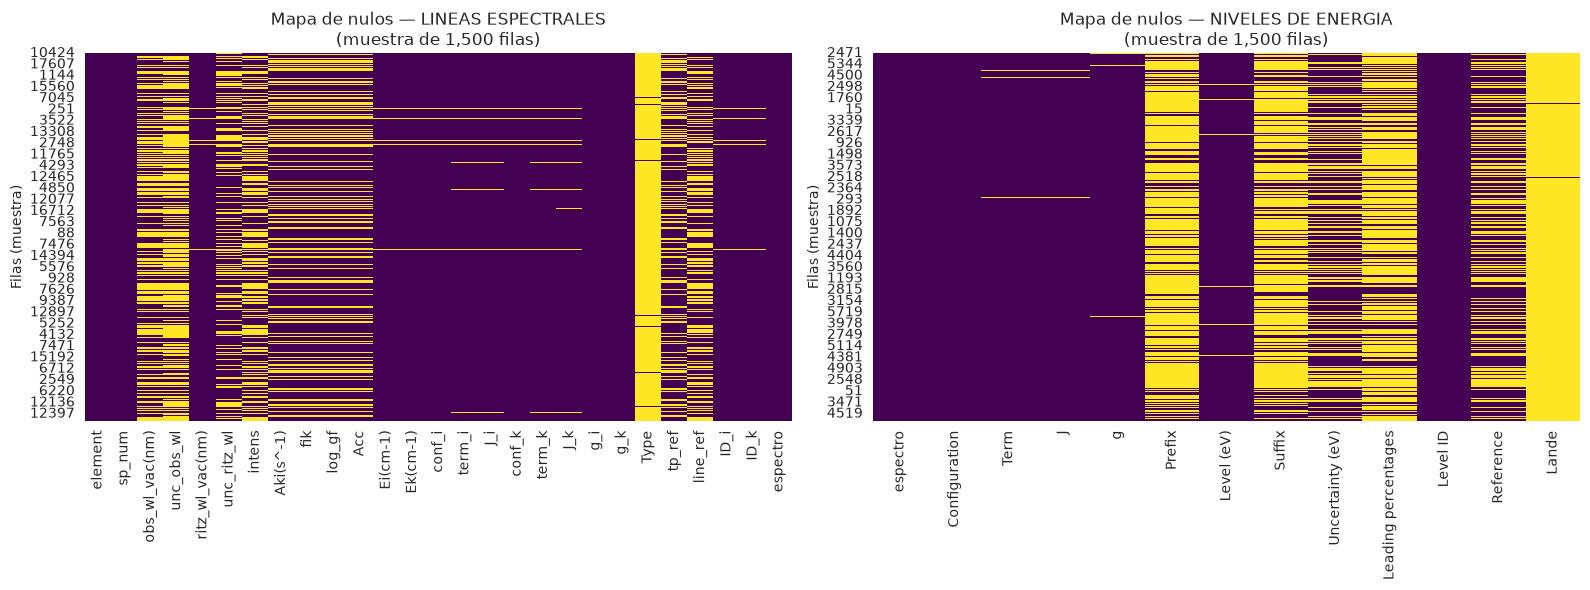

In [39]:
# Mapa de calor de nulos. Se grafica sobre una MUESTRA porque dibujar cientos de miles
# de filas no aporta nada visualmente y satura la memoria.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (nombre, df) in zip(axes, [("LINEAS ESPECTRALES", df_lines), ("NIVELES DE ENERGIA", df_levels)]):
    muestra = df.sample(min(1500, len(df)), random_state=42)
    sns.heatmap(muestra.isnull(), cbar=False, ax=ax, cmap="viridis")
    ax.set_title(f"Mapa de nulos — {nombre}\n(muestra de {len(muestra):,} filas)")
    ax.set_ylabel("Filas (muestra)")

plt.tight_layout()
plt.show()

### Faltantes por espectro

Este cruce es específico de este proyecto y no aparece en los ejemplos de clase, pero es
necesario: la pregunta científica **compara elementos entre sí**. Si un elemento tiene `Aki`
ausente en la mayoría de sus líneas, cualquier comparación entre elementos quedaría sesgada
por la cobertura del catálogo y no por la física.

In [40]:
print("=== Numero de lineas espectrales por espectro ===")
display(df_lines_num["espectro"].value_counts().to_frame("num_lineas"))

=== Numero de lineas espectrales por espectro ===


,num_lineas
espectro,
He I,2300
C I,2102
Ne II,1914
O II,1630
C II,1605
Ne I,1597
N I,1309
O I,910
N II,809


In [41]:
criticas = [COL_L[k] for k in ["wl_obs", "wl_ritz", "aki", "Ei", "Ek"] if COL_L[k]]

nulos_por_espectro = (
    df_lines_num.groupby("espectro")[criticas]
    .apply(lambda g: g.isna().mean() * 100)
    .round(1)
)
nulos_por_espectro["num_lineas"] = df_lines_num.groupby("espectro").size()

print("=== % de valores faltantes en columnas CRITICAS, por espectro ===")
display(nulos_por_espectro.sort_values("num_lineas", ascending=False))

=== % de valores faltantes en columnas CRITICAS, por espectro ===


,obs_wl_vac(nm),ritz_wl_vac(nm),Aki(s^-1),Ei(cm-1),Ek(cm-1),num_lineas
espectro,,,,,,
He I,92.9,0.0,0.5,99.9,99.7,2300
C I,34.2,0.0,23.1,0.0,0.8,2102
Ne II,4.2,0.1,87.8,0.1,0.3,1914
O II,32.4,0.0,46.3,0.9,2.9,1630
C II,39.4,0.0,10.7,0.6,1.6,1605
Ne I,0.1,0.0,66.6,0.0,0.0,1597
N I,88.8,1.7,1.7,1.7,1.7,1309
O I,80.9,6.2,6.2,0.3,0.3,910
N II,86.3,2.8,2.8,2.8,2.8,809


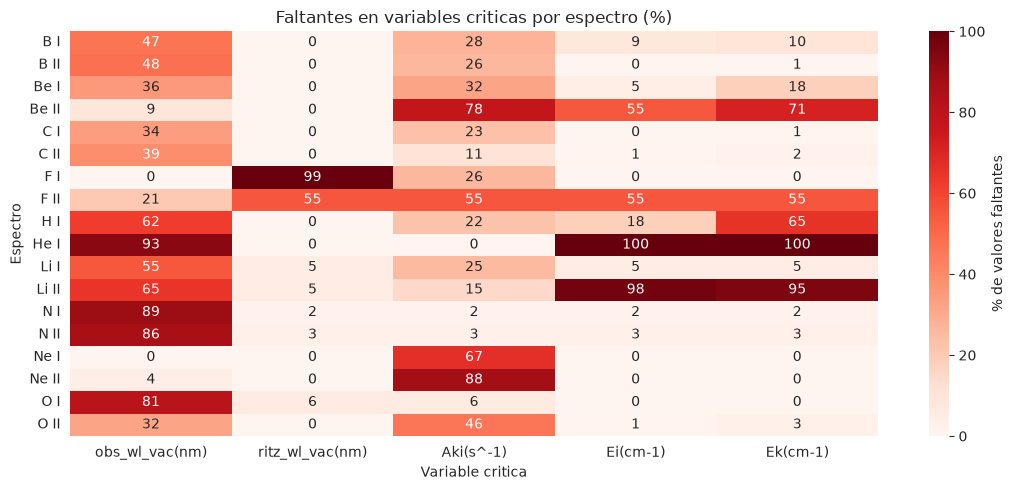

In [42]:
plt.figure(figsize=(11, 5))
sns.heatmap(
    nulos_por_espectro[criticas], annot=True, fmt=".0f", cmap="Reds",
    cbar_kws={"label": "% de valores faltantes"}, vmin=0, vmax=100,
)
plt.title("Faltantes en variables criticas por espectro (%)")
plt.xlabel("Variable critica")
plt.ylabel("Espectro")
plt.tight_layout()
plt.show()

---
# Sección 6 — Estadística descriptiva

`describe()` sobre las numéricas y `describe(include='O')` sobre las categóricas. Como en el
ejemplo de clase, el objetivo no es solo ver medias: es **detectar valores sospechosos antes
de graficar nada**. Ahí, un máximo de 10665 frente a un percentil 75 de 81 delató los
outliers de `User_Count` sin necesidad de un solo gráfico.

In [43]:
print("=== describe() — LINEAS ESPECTRALES (columnas numericas) ===")
display(df_lines_num[NUM_L].describe().T)

=== describe() — LINEAS ESPECTRALES (columnas numericas) ===


,count,mean,std,min,25%,50%,75%,max
sp_num,18288.0,1.439851e+00,4.963825e-01,1.000000e+00,1.000000,1.000000,2.000000e+00,2.000000e+00
obs_wl_vac(nm),9864.0,3.422365e+07,1.092272e+09,4.276700e+00,185.336890,399.713600,7.629668e+02,6.064000e+10
unc_obs_wl,7690.0,1.218456e+06,1.026422e+08,1.500000e-12,0.000400,0.001400,3.000000e-03,9.000000e+09
ritz_wl_vac(nm),17892.0,2.021780e+07,8.290059e+08,4.276600e+00,260.506500,587.140215,1.864402e+03,6.250000e+10
unc_ritz_wl,13268.0,4.779006e+05,5.210117e+07,1.500000e-12,0.000022,0.000400,4.000000e-03,6.000000e+09
intens,6112.0,2.920485e+07,8.417476e+08,0.000000e+00,15.000000,98.000000,5.400000e+02,4.800000e+10
Aki(s^-1),12603.0,4.846888e+08,1.283931e+10,4.240000e-24,25200.000000,446000.000000,6.200000e+06,7.000000e+11
fik,12603.0,1.031501e+05,6.031500e+06,8.030000e-25,0.000800,0.006950,5.057500e-02,6.000000e+08
log_gf,12603.0,-1.802485e+00,1.854753e+00,-2.349300e+01,-2.500000,-1.570000,-6.710000e-01,3.450810e+00
Ei(cm-1),14634.0,1.300602e+05,9.376708e+04,0.000000e+00,66867.617500,107965.056800,1.957105e+05,1.077320e+06


In [44]:
print("=== describe() — NIVELES DE ENERGIA (columnas numericas) ===")
display(df_levels_num[NUM_N].describe().T)

=== describe() — NIVELES DE ENERGIA (columnas numericas) ===


,count,mean,std,min,25%,50%,75%,max
J,3250.0,2.329846,1.624907,0.0,1.000000e+00,2.000000,3.00000,8.00
g,5700.0,13.350000,123.090306,1.0,3.000000e+00,5.000000,7.00000,3200.00
Level (eV),5689.0,29.936724,33.767698,0.0,1.417236e+01,23.239296,30.31550,294.77
Uncertainty (eV),3689.0,0.005294,0.032072,0.0,1.100000e-08,0.000007,0.00004,0.60


In [45]:
print("=== describe(include='O') — LINEAS ESPECTRALES (columnas categoricas) ===")
display(df_lines.describe(include="O").T)

=== describe(include='O') — LINEAS ESPECTRALES (columnas categoricas) ===


/tmp/ipykernel_3847/2995231600.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_lines.describe(include="O").T)


,count,unique,top,freq
element,18290,11,C,3707
sp_num,18290,3,1,10244
obs_wl_vac(nm),9866,8017,49.870,15
unc_obs_wl,7692,164,0.0020,801
ritz_wl_vac(nm),18108,16647,71.421,15
unc_ritz_wl,13270,289,0.003,463
intens,9881,1345,*,328
Aki(s^-1),12605,7162,1.3e+06,24
fik,12605,6865,8.e-04,33
log_gf,12605,7018,-2.5,58


In [46]:
print("=== describe(include='O') — NIVELES DE ENERGIA (columnas categoricas) ===")
display(df_levels.describe(include="O").T)

=== describe(include='O') — NIVELES DE ENERGIA (columnas categoricas) ===


/tmp/ipykernel_3847/3989751635.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_levels.describe(include="O").T)


,count,unique,top,freq
espectro,5752,18,He I,843
Configuration,5751,1399,2s2.2p2.(3P).3d,34
Term,5711,94,3P*,375
J,5704,26,1,888
Prefix,1220,2,[,1209
Level (eV),5689,4795,13.2400126,8
Suffix,1494,14,],1203
Uncertainty (eV),3689,210,0.00000000000025,404
Leading percentages,1761,659,100,520
Level ID,5752,5752,001001.001.000001,1


In [47]:
def detectar_sospechosas(df, columnas, nombre, factor=10):
    # Marca columnas donde el maximo esta desproporcionadamente lejos del percentil 75:
    # el mismo olfato que en el ejemplo de clase delato los outliers antes de graficar.
    filas = []
    for col in columnas:
        s = df[col].dropna()
        if len(s) < 10:
            continue
        q3 = s.quantile(0.75)
        mx = s.max()
        razon = (mx / q3) if q3 not in (0,) and pd.notna(q3) else np.nan
        filas.append({
            "columna": col, "p75": q3, "max": mx, "max/p75": razon,
            "sospechosa": bool(pd.notna(razon) and razon > factor),
        })
    out = pd.DataFrame(filas).sort_values("max/p75", ascending=False)
    print(f"=== Deteccion automatica de escala sospechosa: {nombre} (factor > {factor}) ===")
    return out


display(detectar_sospechosas(df_lines_num, NUM_L, "LINEAS ESPECTRALES"))

=== Deteccion automatica de escala sospechosa: LINEAS ESPECTRALES (factor > 10) ===


,columna,p75,max,max/p75,sospechosa
2,unc_obs_wl,3.000000e-03,9.000000e+09,3.000000e+12,True
4,unc_ritz_wl,4.000000e-03,6.000000e+09,1.500000e+12,True
7,fik,5.057500e-02,6.000000e+08,1.186357e+10,True
5,intens,5.400000e+02,4.800000e+10,8.888889e+07,True
1,obs_wl_vac(nm),7.629668e+02,6.064000e+10,7.947921e+07,True
3,ritz_wl_vac(nm),1.864402e+03,6.250000e+10,3.352281e+07,True
6,Aki(s^-1),6.200000e+06,7.000000e+11,1.129032e+05,True
14,g_k,6.000000e+00,3.200000e+03,5.333333e+02,True
13,g_i,6.000000e+00,1.352000e+03,2.253333e+02,True
10,Ek(cm-1),2.388940e+05,2.377500e+06,9.952114e+00,False


In [48]:
display(detectar_sospechosas(df_levels_num, NUM_N, "NIVELES DE ENERGIA"))

=== Deteccion automatica de escala sospechosa: NIVELES DE ENERGIA (factor > 10) ===


,columna,p75,max,max/p75,sospechosa
3,Uncertainty (eV),0.00004,0.60,15000.000000,True
1,g,7.00000,3200.00,457.142857,True
2,Level (eV),30.31550,294.77,9.723409,False
0,J,3.00000,8.00,2.666667,False


---
# Sección 7 — Inconsistencias, duplicados y validación física

Además de los chequeos estándar de duplicados, aquí se aplica algo que un dataset genérico
no permite: **validar contra las leyes físicas**. Una longitud de onda negativa o una
transición cuyo nivel superior tiene menos energía que el inferior no son "outliers
estadísticos": son imposibles, y por lo tanto errores de dato inequívocos.

Los umbrales no se inventan de antemano: se calculan los rangos reales y se contrastan con
lo que la física permite.

In [49]:
print("=== Duplicados exactos (fila completa) ===")
for nombre, df in [("LINEAS", df_lines), ("NIVELES", df_levels)]:
    n = int(df.duplicated().sum())
    print(f"  {nombre:<8}: {n:,} filas duplicadas ({n / len(df) * 100:.3f}%)")

=== Duplicados exactos (fila completa) ===


  LINEAS  : 0 filas duplicadas (0.000%)


  NIVELES : 0 filas duplicadas (0.000%)


In [50]:
# Duplicados por subconjunto identificador: dos filas pueden diferir solo en una
# referencia bibliografica y describir, aun asi, la MISMA transicion fisica.
sub_l = [c for c in [COL_L["elemento"], COL_L["sp_num"], COL_L["wl_obs"],
                     COL_L["conf_i"], COL_L["term_i"], COL_L["J_i"],
                     COL_L["conf_k"], COL_L["term_k"], COL_L["J_k"]] if c]

n_sub = int(df_lines.duplicated(subset=sub_l).sum())
print(f"Clave usada: {sub_l}")
print(f"Duplicados por identidad fisica de la transicion: {n_sub:,} "
      f"({n_sub / len(df_lines) * 100:.3f}%)")

if n_sub > 0:
    print("\n--- Ejemplo de filas con la misma identidad fisica ---")
    dup_mask = df_lines.duplicated(subset=sub_l, keep=False)
    display(df_lines[dup_mask].sort_values(sub_l).head(6))

Clave usada: ['element', 'sp_num', 'obs_wl_vac(nm)', 'conf_i', 'term_i', 'J_i', 'conf_k', 'term_k', 'J_k']
Duplicados por identidad fisica de la transicion: 70 (0.383%)

--- Ejemplo de filas con la misma identidad fisica ---


,element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1),fik,log_gf,Acc,Ei(cm-1),Ek(cm-1),conf_i,term_i,J_i,conf_k,term_k,J_k,g_i,g_k,Type,tp_ref,line_ref,ID_i,ID_k,espectro
18229,B,1,NaN,NaN,2160000,100000,NaN,2.23e-09,3.11e-10,-9.21,A,28647.43+x,28652.07+x,2s.2p2,4P,1/2,2s.2p2,4P,3/2,2,4,M1,T7194,NaN,005001.000003,005001.000004,B I
18230,B,1,NaN,NaN,2160000,100000,NaN,1.74e-19,2.42e-20,-19.32,B,28647.43+x,28652.07+x,2s.2p2,4P,1/2,2s.2p2,4P,3/2,2,4,E2,T7194,NaN,005001.000003,005001.000004,B I
18225,B,1,NaN,NaN,1580000,30000,NaN,4.10e-09,2.30e-10,-9.04,A,28652.07+x,28658.40+x,2s.2p2,4P,3/2,2s.2p2,4P,5/2,4,6,M1,T7194,NaN,005001.000004,005001.000005,B I
18226,B,1,NaN,NaN,1580000,30000,NaN,7.00e-18,3.93e-19,-17.80,B,28652.07+x,28658.40+x,2s.2p2,4P,3/2,2s.2p2,4P,5/2,4,6,E2,T7194,NaN,005001.000004,005001.000005,B I
18194,B,1,NaN,NaN,654150,130,NaN,3.20e-08,4.11e-10,-9.09,A,0.0000,15.287,2s2.2p,2P*,1/2,2s2.2p,2P*,3/2,2,4,M1,T7194,NaN,005001.000001,005001.000002,B I
18195,B,1,NaN,NaN,654150,130,NaN,6.24e-16,8.01e-18,-16.80,B,0.0000,15.287,2s2.2p,2P*,1/2,2s2.2p,2P*,3/2,2,4,E2,T7194,NaN,005001.000001,005001.000002,B I


In [51]:
sub_n = [c for c in [COL_N["espectro"], COL_N["conf"], COL_N["term"], COL_N["J"]] if c]
n_sub_n = int(df_levels.duplicated(subset=sub_n).sum())
print(f"Clave usada en niveles: {sub_n}")
print(f"Niveles con identidad cuantica repetida dentro del mismo espectro: {n_sub_n:,} "
      f"({n_sub_n / len(df_levels) * 100:.3f}%)")
print()
print("Esto es decisivo para la Seccion 11: si la clave no es unica, un merge por ella")
print("DUPLICARIA filas del dataset de lineas.")

if n_sub_n > 0:
    dup_mask_n = df_levels.duplicated(subset=sub_n, keep=False)
    display(df_levels[dup_mask_n].sort_values(sub_n).head(8))

Clave usada en niveles: ['espectro', 'Configuration', 'Term', 'J']
Niveles con identidad cuantica repetida dentro del mismo espectro: 16 (0.278%)

Esto es decisivo para la Seccion 11: si la clave no es unica, un merge por ella
DUPLICARIA filas del dataset de lineas.


,espectro,Configuration,Term,J,g,Prefix,Level (eV),Suffix,Uncertainty (eV),Leading percentages,Level ID,Reference,Lande
4931,F II,2s2.2p3.(2D*).4f,2[3/2],1,3.0,NaN,35.785692,NaN,NaN,NaN,009002.000231,NaN,NaN
4944,F II,2s2.2p3.(2D*).4f,2[3/2],1,3.0,NaN,35.792080,NaN,NaN,NaN,009002.000244,NaN,NaN
4930,F II,2s2.2p3.(2D*).4f,2[3/2],2,5.0,NaN,35.785383,NaN,NaN,NaN,009002.000228,NaN,NaN
4945,F II,2s2.2p3.(2D*).4f,2[3/2],2,5.0,NaN,35.792285,NaN,NaN,NaN,009002.000245,NaN,NaN
4932,F II,2s2.2p3.(2D*).4f,2[5/2],2,5.0,NaN,35.786064,NaN,NaN,NaN,009002.000232,NaN,NaN
4940,F II,2s2.2p3.(2D*).4f,2[5/2],2,5.0,NaN,35.789723,NaN,NaN,NaN,009002.000240,NaN,NaN
4933,F II,2s2.2p3.(2D*).4f,2[5/2],3,7.0,NaN,35.786132,NaN,NaN,NaN,009002.000233,NaN,NaN
4941,F II,2s2.2p3.(2D*).4f,2[5/2],3,7.0,NaN,35.789868,NaN,NaN,NaN,009002.000241,NaN,NaN


In [52]:
print("=== Validacion fisica: valores imposibles en LINEAS ===")
validaciones = []


def registrar(descripcion, mascara, total):
    n = int(mascara.sum())
    validaciones.append({
        "validacion": descripcion, "violaciones": n,
        "%": round(n / total * 100, 4) if total else 0.0,
    })


n_tot = len(df_lines_num)

for clave, etiqueta in [("wl_obs", "longitud de onda observada"), ("wl_ritz", "longitud de onda Ritz")]:
    col = COL_L[clave]
    if col:
        registrar(f"{etiqueta} <= 0 (imposible)", df_lines_num[col] <= 0, n_tot)

if COL_L["aki"]:
    registrar("Aki <= 0 (probabilidad no positiva, imposible)", df_lines_num[COL_L["aki"]] <= 0, n_tot)

if COL_L["Ei"] and COL_L["Ek"]:
    registrar(
        "Ek <= Ei (nivel superior no supera al inferior, imposible)",
        df_lines_num[COL_L["Ek"]] <= df_lines_num[COL_L["Ei"]], n_tot,
    )
    registrar("Ei < 0 (energia de nivel negativa)", df_lines_num[COL_L["Ei"]] < 0, n_tot)

display(pd.DataFrame(validaciones))

=== Validacion fisica: valores imposibles en LINEAS ===


,validacion,violaciones,%
0,longitud de onda observada <= 0 (imposible),0,0.0
1,longitud de onda Ritz <= 0 (imposible),0,0.0
2,"Aki <= 0 (probabilidad no positiva, imposible)",0,0.0
3,"Ek <= Ei (nivel superior no supera al inferior, imposible)",0,0.0
4,Ei < 0 (energia de nivel negativa),0,0.0


In [53]:
# Coherencia entre longitud de onda observada y Ritz: deberian ser casi iguales.
# Una discrepancia grande delata un registro internamente inconsistente.
if COL_L["wl_obs"] and COL_L["wl_ritz"]:
    obs = df_lines_num[COL_L["wl_obs"]]
    ritz = df_lines_num[COL_L["wl_ritz"]]
    ambas = obs.notna() & ritz.notna()
    dif = (obs - ritz).abs()
    dif_rel = (dif / ritz * 100)

    print(f"Filas con AMBAS longitudes de onda: {int(ambas.sum()):,} "
          f"({ambas.mean() * 100:.1f}% del total)")
    print(f"Filas con SOLO observada          : {int((obs.notna() & ritz.isna()).sum()):,}")
    print(f"Filas con SOLO Ritz               : {int((obs.isna() & ritz.notna()).sum()):,}")
    print(f"Filas SIN NINGUNA                 : {int((obs.isna() & ritz.isna()).sum()):,}")
    print()
    print("Diferencia absoluta |observada - Ritz| en nm:")
    display(dif[ambas].describe().to_frame("nm"))
    print("Diferencia relativa (%):")
    display(dif_rel[ambas].describe().to_frame("%"))
    print(f"Registros con discrepancia relativa > 1%: {int((dif_rel > 1).sum()):,}")

Filas con AMBAS longitudes de onda: 9,468 (51.8% del total)
Filas con SOLO observada          : 396
Filas con SOLO Ritz               : 8,424
Filas SIN NINGUNA                 : 2

Diferencia absoluta |observada - Ritz| en nm:


,nm
count,9.468000e+03
mean,5.134927e+05
std,2.606598e+07
min,0.000000e+00
25%,8.500000e-05
50%,3.800000e-04
75%,1.500000e-03
max,1.860000e+09


Diferencia relativa (%):


,%
count,9468.000000
mean,0.003300
std,0.054735
min,0.000000
25%,0.000013
50%,0.000088
75%,0.000422
max,2.976000


Registros con discrepancia relativa > 1%: 5


In [54]:
# Consistencia cuantica en niveles: por definicion g = 2J + 1.
col_J, col_g = COL_N.get("J"), COL_N.get("g")
if col_J and col_g:
    # J puede venir como fraccion ('3/2'), asi que se evalua explicitamente.
    def parse_J(v):
        t = str(v).strip().replace('"', "").lstrip("=")
        if "/" in t:
            try:
                a, b = t.split("/")
                return float(a) / float(b)
            except Exception:
                return np.nan
        try:
            return float(t)
        except Exception:
            return np.nan

    J_num = df_levels[col_J].map(parse_J)
    g_num = pd.to_numeric(quitar_artefacto(df_levels[col_g]), errors="coerce")
    evaluable = J_num.notna() & g_num.notna()
    coincide = (g_num == (2 * J_num + 1)) & evaluable

    print(f"Niveles con J y g evaluables      : {int(evaluable.sum()):,}")
    print(f"Cumplen g = 2J + 1                : {int(coincide.sum()):,} "
          f"({coincide.sum() / max(evaluable.sum(), 1) * 100:.2f}%)")
    print(f"NO cumplen (inconsistencia cuantica): {int((evaluable & ~coincide).sum()):,}")
    print(f"J no interpretable como numero     : {int(df_levels[col_J].notna().sum() - J_num.notna().sum()):,}")

    if int((evaluable & ~coincide).sum()) > 0:
        display(df_levels.loc[evaluable & ~coincide, [COL_N["espectro"], col_J, col_g]].head(8))

Niveles con J y g evaluables      : 5,570
Cumplen g = 2J + 1                : 5,570 (100.00%)
NO cumplen (inconsistencia cuantica): 0
J no interpretable como numero     : 134


In [55]:
# Inconsistencias de formato en columnas de texto: espacios sobrantes o mayusculas
# distintas hacen que el mismo valor cuente como dos categorias distintas.
print("=== Inconsistencias de formato en columnas de texto ===")
filas_fmt = []

pares = (
    [("LINEAS", df_lines, c) for c in [COL_L["elemento"], COL_L["conf_i"], COL_L["term_i"],
                                       COL_L["conf_k"], COL_L["term_k"]] if c]
    + [("NIVELES", df_levels, c) for c in [COL_N["conf"], COL_N["term"]] if c]
)

for fuente, df, col in pares:
    s = df[col].dropna().astype(str)
    if s.empty:
        continue
    filas_fmt.append({
        "fuente": fuente,
        "columna": col,
        "unicos_crudos": s.nunique(),
        "unicos_tras_strip": s.str.strip().nunique(),
        "unicos_tras_normalizar": normalizar_texto(s).nunique(),
        "con_espacios_sobrantes": int((s != s.str.strip()).sum()),
        "con_artefacto_=": int(s.str.startswith("=").sum()),
    })

fmt = pd.DataFrame(filas_fmt)
fmt["colapsan_al_normalizar"] = fmt["unicos_crudos"] - fmt["unicos_tras_normalizar"]
display(fmt)

=== Inconsistencias de formato en columnas de texto ===


,fuente,columna,unicos_crudos,unicos_tras_strip,unicos_tras_normalizar,con_espacios_sobrantes,con_artefacto_=,colapsan_al_normalizar
0,LINEAS,element,11,11,11,0,0,0
1,LINEAS,conf_i,307,307,307,0,0,0
2,LINEAS,term_i,72,72,72,0,0,0
3,LINEAS,conf_k,862,862,862,0,0,0
4,LINEAS,term_k,81,81,81,0,0,0
5,NIVELES,Configuration,1399,1399,1399,0,0,0
6,NIVELES,Term,94,94,94,0,0,0


---
# Sección 8 — Distribución de las variables

Para cada variable numérica relevante se estudia la **forma** de su distribución. Esto no es
decorativo: la elección entre imputar con media o con mediana depende directamente de si la
distribución es simétrica o sesgada, y esa decisión se toma mirando estos gráficos, tal como
en el ejemplo de clase.

**Sobre la escala logarítmica:** `Aki` varía en muchos órdenes de magnitud (de ~10⁻⁵ a ~10⁹
s⁻¹). En escala lineal, su histograma es una sola barra pegada al cero y no informa nada.
Por eso se grafica en log.

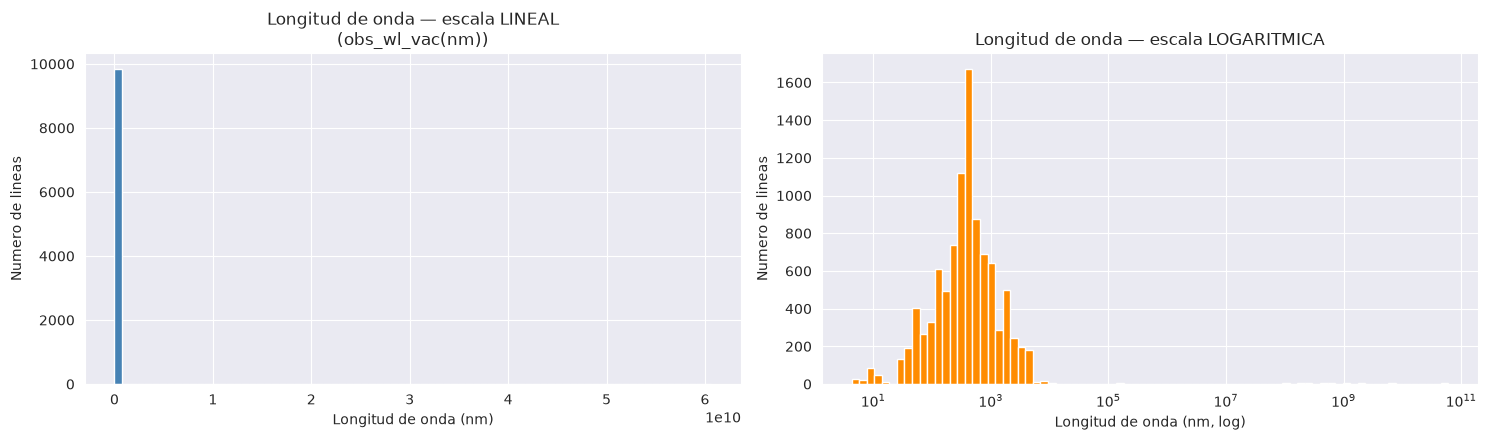

Rango de longitud de onda: 4.2767 nm  a  60,640,000,000.00 nm
Abarca 10.2 ordenes de magnitud.


In [56]:
col_wl = COL_L["wl_obs"] or COL_L["wl_ritz"]

if col_wl:
    wl = df_lines_num[col_wl].dropna()
    wl_pos = wl[wl > 0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

    axes[0].hist(wl_pos, bins=80, color="steelblue", edgecolor="white")
    axes[0].set_title(f"Longitud de onda — escala LINEAL\n({col_wl})")
    axes[0].set_xlabel("Longitud de onda (nm)")
    axes[0].set_ylabel("Numero de lineas")

    axes[1].hist(wl_pos, bins=np.logspace(np.log10(wl_pos.min()), np.log10(wl_pos.max()), 80),
                 color="darkorange", edgecolor="white")
    axes[1].set_xscale("log")
    axes[1].set_title("Longitud de onda — escala LOGARITMICA")
    axes[1].set_xlabel("Longitud de onda (nm, log)")
    axes[1].set_ylabel("Numero de lineas")

    plt.tight_layout()
    plt.show()

    print(f"Rango de longitud de onda: {wl_pos.min():.4f} nm  a  {wl_pos.max():,.2f} nm")
    print(f"Abarca {np.log10(wl_pos.max() / wl_pos.min()):.1f} ordenes de magnitud.")

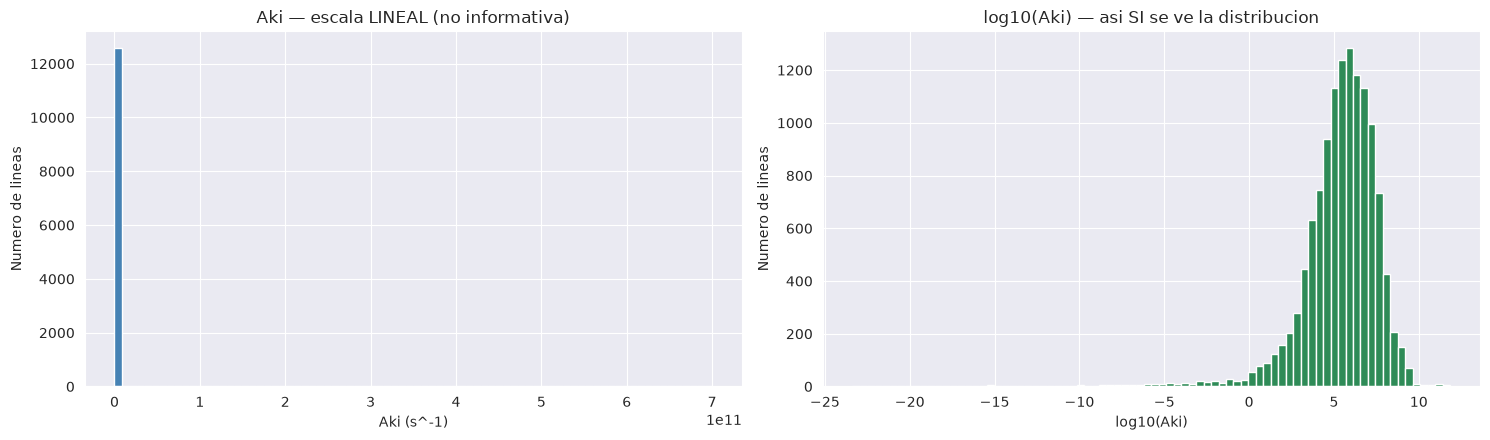

Aki disponible en 12,603 de 18,290 lineas (68.9%)
Rango: 4.240e-24  a  7.000e+11 s^-1
Abarca 35.2 ordenes de magnitud.

Asimetria (skew) de Aki crudo      : 40.16
Asimetria (skew) de log10(Aki)     : -2.54

Una asimetria alta en el valor crudo significa que la MEDIA esta arrastrada por
la cola: en esa situacion la MEDIANA es el estadistico robusto para imputar.


In [57]:
col_aki = COL_L["aki"]

if col_aki:
    aki = df_lines_num[col_aki].dropna()
    aki_pos = aki[aki > 0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

    axes[0].hist(aki_pos, bins=80, color="steelblue", edgecolor="white")
    axes[0].set_title("Aki — escala LINEAL (no informativa)")
    axes[0].set_xlabel("Aki (s^-1)")
    axes[0].set_ylabel("Numero de lineas")

    axes[1].hist(np.log10(aki_pos), bins=80, color="seagreen", edgecolor="white")
    axes[1].set_title("log10(Aki) — asi SI se ve la distribucion")
    axes[1].set_xlabel("log10(Aki)")
    axes[1].set_ylabel("Numero de lineas")

    plt.tight_layout()
    plt.show()

    print(f"Aki disponible en {len(aki):,} de {len(df_lines_num):,} lineas "
          f"({len(aki) / len(df_lines_num) * 100:.1f}%)")
    print(f"Rango: {aki_pos.min():.3e}  a  {aki_pos.max():.3e} s^-1")
    print(f"Abarca {np.log10(aki_pos.max() / aki_pos.min()):.1f} ordenes de magnitud.")
    print()
    print("Asimetria (skew) de Aki crudo      :", round(float(aki.skew()), 2))
    print("Asimetria (skew) de log10(Aki)     :", round(float(np.log10(aki_pos).skew()), 2))
    print()
    print("Una asimetria alta en el valor crudo significa que la MEDIA esta arrastrada por")
    print("la cola: en esa situacion la MEDIANA es el estadistico robusto para imputar.")

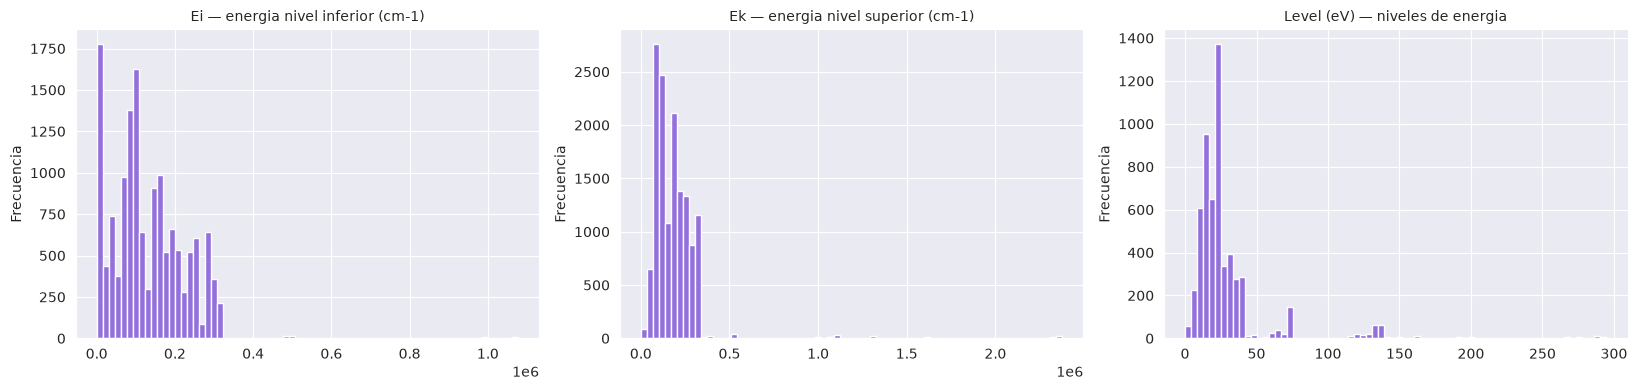

Ei — energia nivel inferior (cm-1)            n= 14,634  min=       0.000  max= 1,077,320.000  skew=   1.27
Ek — energia nivel superior (cm-1)            n= 14,117  min=      15.287  max= 2,377,500.000  skew=   7.61
Level (eV) — niveles de energia               n=  5,689  min=       0.000  max=       294.770  skew=   4.34


In [58]:
# Distribucion de las energias de nivel en ambas fuentes.
graficables = []
if COL_L["Ei"]:
    graficables.append(("Ei — energia nivel inferior (cm-1)", df_lines_num[COL_L["Ei"]].dropna()))
if COL_L["Ek"]:
    graficables.append(("Ek — energia nivel superior (cm-1)", df_lines_num[COL_L["Ek"]].dropna()))
if COL_N["nivel"]:
    graficables.append(("Level (eV) — niveles de energia", df_levels_num[COL_N["nivel"]].dropna()))

if graficables:
    fig, axes = plt.subplots(1, len(graficables), figsize=(5.5 * len(graficables), 4))
    if len(graficables) == 1:
        axes = [axes]
    for ax, (titulo, serie) in zip(axes, graficables):
        ax.hist(serie, bins=70, color="mediumpurple", edgecolor="white")
        ax.set_title(titulo, fontsize=10)
        ax.set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

    for titulo, serie in graficables:
        print(f"{titulo:<45} n={len(serie):>7,}  min={serie.min():>12,.3f}  "
              f"max={serie.max():>14,.3f}  skew={serie.skew():>7.2f}")

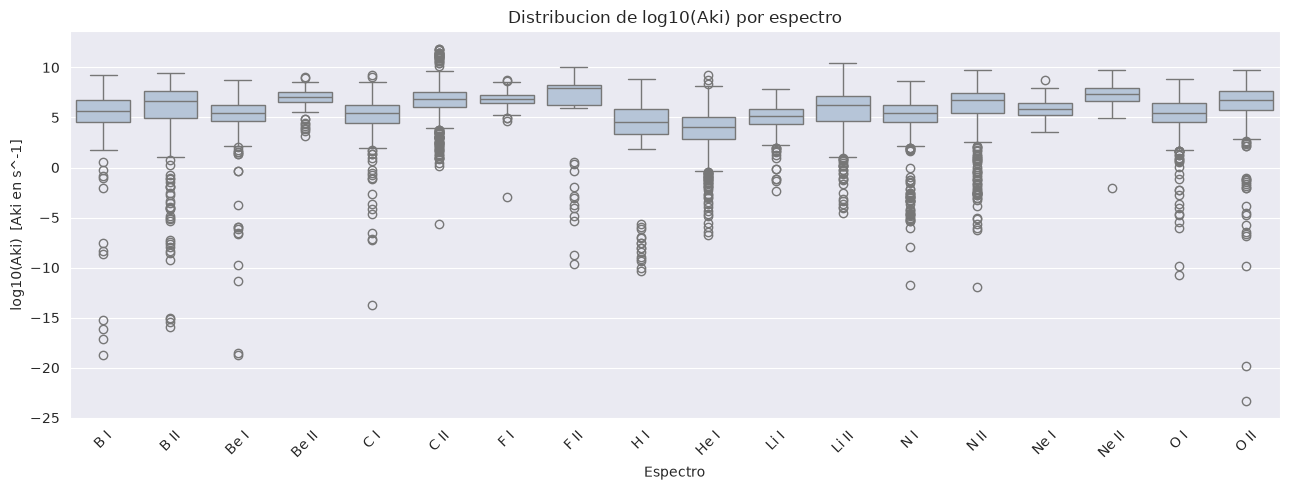

In [59]:
# Boxplots por espectro: permiten comparar visualmente los 10 elementos entre si,
# que es exactamente lo que pide la pregunta cientifica.
if col_aki and "espectro" in df_lines_num.columns:
    datos = df_lines_num[[COL_L["elemento"], "espectro", col_aki]].dropna(subset=[col_aki])
    datos = datos[datos[col_aki] > 0].copy()
    datos["log10_Aki"] = np.log10(datos[col_aki])

    plt.figure(figsize=(13, 5))
    orden = sorted(datos["espectro"].unique())
    sns.boxplot(data=datos, x="espectro", y="log10_Aki", order=orden, color="lightsteelblue")
    plt.title("Distribucion de log10(Aki) por espectro")
    plt.xlabel("Espectro")
    plt.ylabel("log10(Aki)  [Aki en s^-1]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

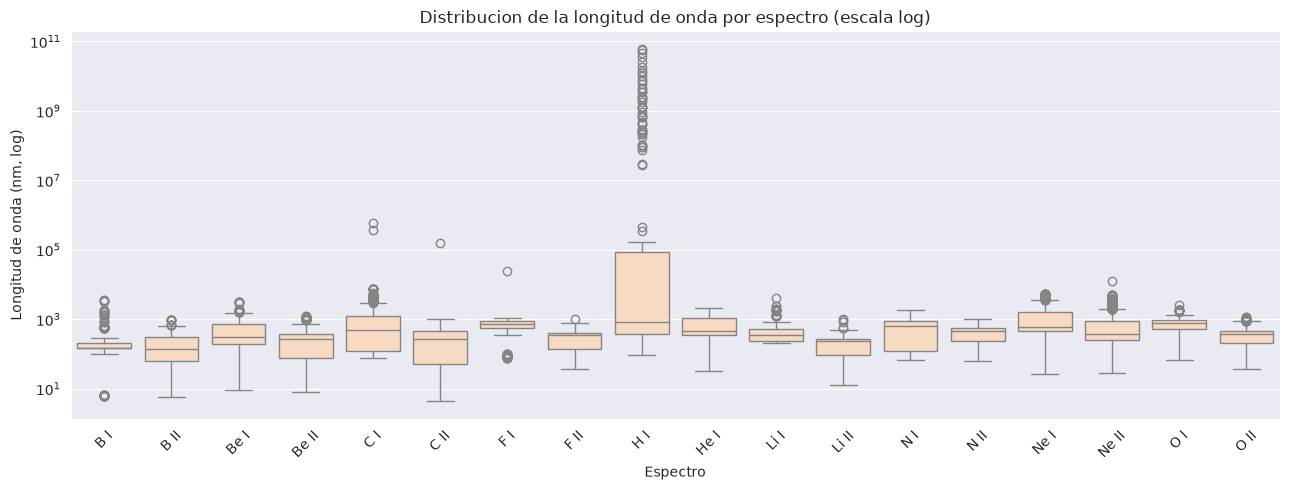

In [60]:
if col_wl and "espectro" in df_lines_num.columns:
    datos_wl = df_lines_num[["espectro", col_wl]].dropna()
    datos_wl = datos_wl[datos_wl[col_wl] > 0]

    plt.figure(figsize=(13, 5))
    sns.boxplot(data=datos_wl, x="espectro", y=col_wl,
                order=sorted(datos_wl["espectro"].unique()), color="peachpuff")
    plt.yscale("log")
    plt.title("Distribucion de la longitud de onda por espectro (escala log)")
    plt.xlabel("Espectro")
    plt.ylabel("Longitud de onda (nm, log)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### El gráfico que ataca directamente la pregunta científica

Dispersión de **longitud de onda frente a Aki**, coloreada por elemento y en escala log-log.
Es la visualización que conecta las dos variables de la pregunta.

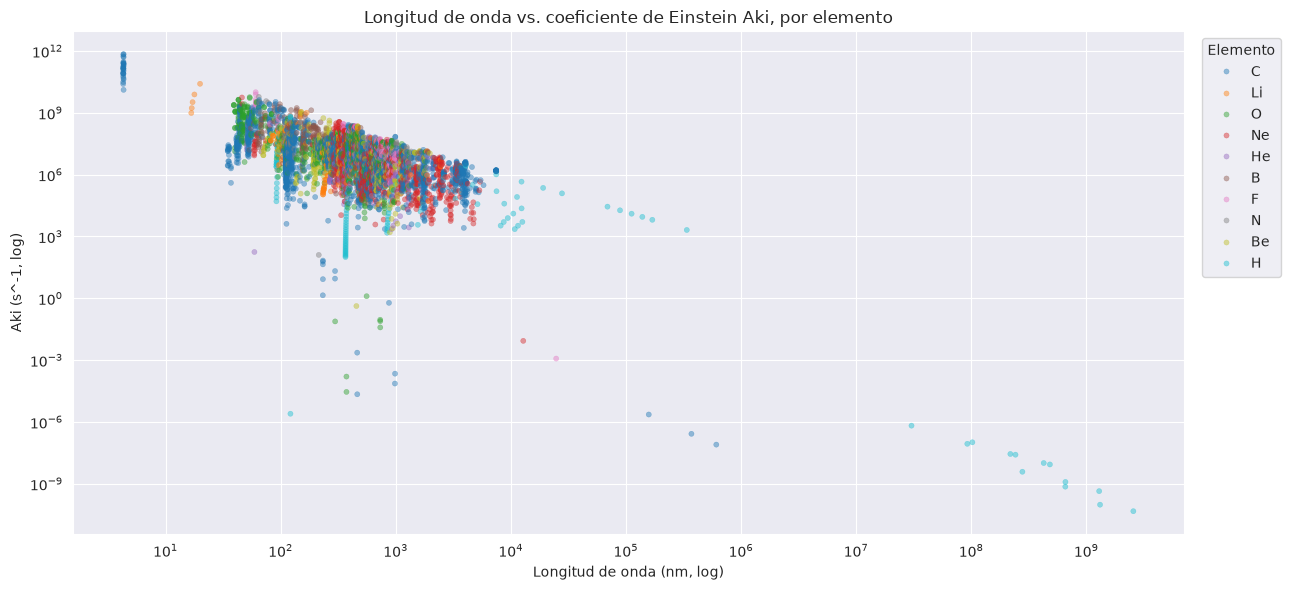

Puntos graficados (lineas con AMBAS variables): 4,462 de 18,290 (24.4%)

La fraccion de lineas utilizable para responder la pregunta cientifica es
exactamente este porcentaje: es el dato mas importante del diagnostico.


In [61]:
if col_wl and col_aki and COL_L["elemento"]:
    d = df_lines_num[[COL_L["elemento"], "espectro", col_wl, col_aki]].dropna()
    d = d[(d[col_wl] > 0) & (d[col_aki] > 0)]

    plt.figure(figsize=(13, 6))
    sns.scatterplot(data=d, x=col_wl, y=col_aki, hue=COL_L["elemento"],
                    alpha=0.45, s=14, palette="tab10", edgecolor=None)
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Longitud de onda vs. coeficiente de Einstein Aki, por elemento")
    plt.xlabel("Longitud de onda (nm, log)")
    plt.ylabel("Aki (s^-1, log)")
    plt.legend(title="Elemento", bbox_to_anchor=(1.01, 1), loc="upper left", ncol=1)
    plt.tight_layout()
    plt.show()

    print(f"Puntos graficados (lineas con AMBAS variables): {len(d):,} "
          f"de {len(df_lines_num):,} ({len(d) / len(df_lines_num) * 100:.1f}%)")
    print()
    print("La fraccion de lineas utilizable para responder la pregunta cientifica es")
    print("exactamente este porcentaje: es el dato mas importante del diagnostico.")

### Región espectral

Se deriva una variable de **diagnóstico** que clasifica cada línea en UV / visible / IR. No
es una transformación de limpieza: es la manera de responder la primera mitad de la pregunta
científica ("cómo se distribuyen a lo largo del espectro electromagnético").

=== Distribucion de lineas por region del espectro electromagnetico ===


,num_lineas,%
region_espectral,,
Rayos X,113,0.62
Ultravioleta,4613,25.22
Visible,2692,14.72
Infrarrojo,2398,13.11
Microondas/Radio,48,0.26
sin dato,8426,46.07


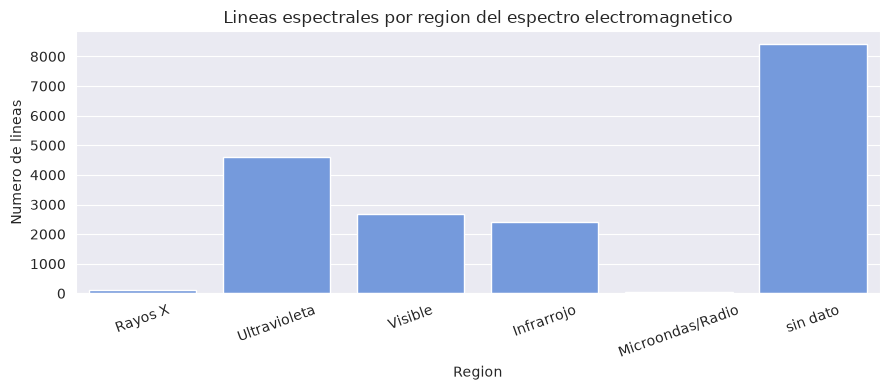

In [62]:
if col_wl:
    def region_espectral(nm):
        if pd.isna(nm) or nm <= 0:
            return "sin dato"
        if nm < 10:
            return "Rayos X"
        if nm < 380:
            return "Ultravioleta"
        if nm <= 780:
            return "Visible"
        if nm <= 1e6:
            return "Infrarrojo"
        return "Microondas/Radio"

    df_lines_num["region_espectral"] = df_lines_num[col_wl].map(region_espectral)

    ORDEN_REG = ["Rayos X", "Ultravioleta", "Visible", "Infrarrojo", "Microondas/Radio", "sin dato"]
    conteo_reg = df_lines_num["region_espectral"].value_counts().reindex(ORDEN_REG).dropna()

    print("=== Distribucion de lineas por region del espectro electromagnetico ===")
    tabla_reg = conteo_reg.to_frame("num_lineas")
    tabla_reg["%"] = (tabla_reg["num_lineas"] / len(df_lines_num) * 100).round(2)
    display(tabla_reg)

    plt.figure(figsize=(9, 4))
    sns.barplot(x=conteo_reg.index, y=conteo_reg.values, color="cornflowerblue")
    plt.title("Lineas espectrales por region del espectro electromagnetico")
    plt.xlabel("Region")
    plt.ylabel("Numero de lineas")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

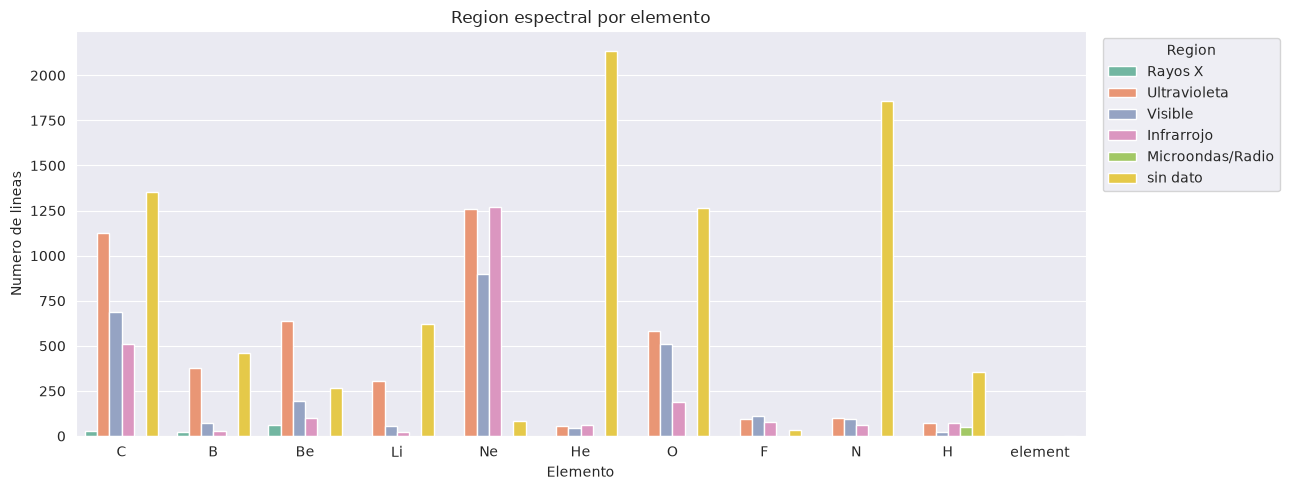

In [63]:
if col_wl and COL_L["elemento"]:
    presentes = [r for r in ORDEN_REG if r in set(df_lines_num["region_espectral"])]
    plt.figure(figsize=(13, 5))
    sns.countplot(data=df_lines_num, x=COL_L["elemento"], hue="region_espectral",
                  hue_order=presentes, palette="Set2")
    plt.title("Region espectral por elemento")
    plt.xlabel("Elemento")
    plt.ylabel("Numero de lineas")
    plt.legend(title="Region", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### Aclaración: no aplica análisis de series temporales

Los datos del NIST ASD **no tienen componente temporal**. No son mediciones repetidas en el
tiempo, sino **propiedades atómicas fijas**: la longitud de onda de la línea Hα del
hidrógeno es la misma hoy que hace un siglo. Las únicas fechas asociadas son las de las
publicaciones bibliográficas, que describen *cuándo se midió*, no *cómo evoluciona el
fenómeno*.

Por eso no se construye ninguna serie temporal: hacerlo sería forzar un gráfico sin
significado físico. Se documenta explícitamente esta decisión en lugar de omitirla.

---
# Sección 9 — Rango de las variables y detección de valores atípicos

Se aplica el método del **rango intercuartílico (IQR)** igual que en el ejemplo de clase:

```
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
bigote_inferior = q1 - 1.5 * iqr
bigote_superior = q3 + 1.5 * iqr
outliers = df[(df[col] < bigote_inferior) | (df[col] > bigote_superior)]
```

**Diferencia crucial respecto al ejemplo de clase:** allí un outlier de `User_Count` era
plausiblemente un error. Aquí, en física atómica, un valor atípico suele ser una **transición
real pero poco común** — una línea muy débil, muy energética o prohibida. Por eso en esta
sección **no se elimina ni se imputa nada**: solo se cuantifica y se inspeccionan casos
concretos, para poder argumentar en el plan de limpieza qué se conserva y qué no.

In [64]:
def tabla_iqr(df, columnas, nombre):
    filas = []
    for col in columnas:
        s = df[col].dropna()
        if len(s) < 10:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        bi, bs = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        out = s[(s < bi) | (s > bs)]
        filas.append({
            "columna": col, "n": len(s),
            "min": s.min(), "max": s.max(), "rango": s.max() - s.min(),
            "q1": q1, "mediana": s.median(), "q3": q3, "iqr": iqr,
            "bigote_inf": bi, "bigote_sup": bs,
            "outliers": len(out),
            "%_outliers": round(len(out) / len(s) * 100, 2),
            "skew": round(float(s.skew()), 2),
        })
    print(f"=== Rango y outliers por IQR: {nombre} ===")
    return pd.DataFrame(filas).sort_values("%_outliers", ascending=False)


iqr_lines = tabla_iqr(df_lines_num, NUM_L, "LINEAS ESPECTRALES")
display(iqr_lines)

=== Rango y outliers por IQR: LINEAS ESPECTRALES ===


,columna,n,min,max,rango,q1,mediana,q3,iqr,bigote_inf,bigote_sup,outliers,%_outliers,skew
5,intens,6112,0.000000e+00,4.800000e+10,4.800000e+10,15.000000,98.000000,5.400000e+02,5.250000e+02,-7.725000e+02,1.327500e+03,1200,19.63,39.92
4,unc_ritz_wl,13268,1.500000e-12,6.000000e+09,6.000000e+09,0.000022,0.000400,4.000000e-03,3.978000e-03,-5.945000e-03,9.967000e-03,2299,17.33,115.11
6,Aki(s^-1),12603,4.240000e-24,7.000000e+11,7.000000e+11,25200.000000,446000.000000,6.200000e+06,6.174800e+06,-9.237000e+06,1.546220e+07,2181,17.31,40.16
7,fik,12603,8.030000e-25,6.000000e+08,6.000000e+08,0.000800,0.006950,5.057500e-02,4.977500e-02,-7.386250e-02,1.252375e-01,1902,15.09,87.94
2,unc_obs_wl,7690,1.500000e-12,9.000000e+09,9.000000e+09,0.000400,0.001400,3.000000e-03,2.600000e-03,-3.500000e-03,6.900000e-03,1003,13.04,87.66
3,ritz_wl_vac(nm),17892,4.276600e+00,6.250000e+10,6.250000e+10,260.506500,587.140215,1.864402e+03,1.603895e+03,-2.145337e+03,4.270245e+03,2267,12.67,57.79
1,obs_wl_vac(nm),9864,4.276700e+00,6.064000e+10,6.064000e+10,185.336890,399.713600,7.629668e+02,5.776299e+02,-6.811079e+02,1.629412e+03,1194,12.10,43.78
11,J_i,9558,0.000000e+00,8.000000e+00,8.000000e+00,1.000000,2.000000,2.000000e+00,1.000000e+00,-5.000000e-01,3.500000e+00,801,8.38,0.94
14,g_k,18288,1.000000e+00,3.200000e+03,3.199000e+03,3.000000,5.000000,6.000000e+00,3.000000e+00,-1.500000e+00,1.050000e+01,821,4.49,16.11
8,log_gf,12603,-2.349300e+01,3.450810e+00,2.694381e+01,-2.500000,-1.570000,-6.710000e-01,1.829000e+00,-5.243500e+00,2.072500e+00,411,3.26,-2.90


In [65]:
iqr_levels = tabla_iqr(df_levels_num, NUM_N, "NIVELES DE ENERGIA")
display(iqr_levels)

=== Rango y outliers por IQR: NIVELES DE ENERGIA ===


,columna,n,min,max,rango,q1,mediana,q3,iqr,bigote_inf,bigote_sup,outliers,%_outliers,skew
3,Uncertainty (eV),3689,0.0,0.60,0.60,1.100000e-08,0.000007,0.00004,0.00004,-0.00006,0.00010,782,21.20,13.07
2,Level (eV),5689,0.0,294.77,294.77,1.417236e+01,23.239296,30.31550,16.14314,-10.04235,54.53021,505,8.88,4.34
1,g,5700,1.0,3200.00,3199.00,3.000000e+00,5.000000,7.00000,4.00000,-3.00000,13.00000,142,2.49,18.88
0,J,3250,0.0,8.00,8.00,1.000000e+00,2.000000,3.00000,2.00000,-2.00000,6.00000,42,1.29,0.73


In [66]:
# Inspeccion de outliers REALES: hay que ver que linea es, de que elemento y con que
# valor, para poder juzgar si es error de dato o fisica legitima.
if col_aki:
    s = df_lines_num[col_aki].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    bs = q3 + 1.5 * iqr
    bi = q1 - 1.5 * iqr

    cols_ver = [c for c in [COL_L["elemento"], "espectro", col_wl, col_aki,
                            COL_L["tipo"], COL_L["acc"], COL_L["conf_i"], COL_L["conf_k"]] if c]

    altos = df_lines_num[df_lines_num[col_aki] > bs].nlargest(8, col_aki)
    print(f"Bigote superior de Aki: {bs:.4e} s^-1")
    print(f"Lineas por encima     : {int((df_lines_num[col_aki] > bs).sum()):,}")
    print("\n--- Las 8 lineas con Aki MAS ALTO (candidatas a outlier superior) ---")
    display(altos[cols_ver])

    bajos = df_lines_num[df_lines_num[col_aki] > 0].nsmallest(8, col_aki)
    print("\n--- Las 8 lineas con Aki MAS BAJO ---")
    display(bajos[cols_ver])

Bigote superior de Aki: 1.5462e+07 s^-1
Lineas por encima     : 2,181

--- Las 8 lineas con Aki MAS ALTO (candidatas a outlier superior) ---


,element,espectro,obs_wl_vac(nm),Aki(s^-1),Type,Acc,conf_i,conf_k
25,C,C II,4.3169,7.000000e+11,NaN,E,2s.2p2,1s.2s.(3S). 2p3.(4S*)
10,C,C II,4.2988,6.800000e+11,NaN,D+,2s2.2p,1s.2s2.2p2
11,C,C II,4.2988,5.500000e+11,NaN,D+,2s2.2p,1s.2s2.2p2
26,C,C II,4.3169,5.000000e+11,NaN,E,2s.2p2,1s.2s.(3S). 2p3.(4S*)
14,C,C II,4.3060,3.000000e+11,NaN,D+,2s2.2p,1s.2s2.2p2
12,C,C II,4.2988,2.700000e+11,NaN,D+,2s2.2p,1s.2s2.2p2
13,C,C II,4.3060,2.500000e+11,NaN,D+,2s2.2p,1s.2s2.2p2
18,C,C II,4.3150,2.500000e+11,NaN,E,2s.2p2,1s.2s.(3S). 2p3.(2D*)



--- Las 8 lineas con Aki MAS BAJO ---


,element,espectro,obs_wl_vac(nm),Aki(s^-1),Type,Acc,conf_i,conf_k
18236,O,O II,NaN,4.240000e-24,E2,E,2s2.2p3,2s2.2p3
18179,O,O II,NaN,1.490000e-20,E2,E,2s2.2p3,2s2.2p3
18230,B,B I,NaN,1.740000e-19,E2,B,2s.2p2,2s.2p2
18234,Be,Be I,NaN,1.860000e-19,E2,B,1s2.2s.2p,1s2.2s.2p
18233,Be,Be I,NaN,2.780000e-19,E2,B,1s2.2s.2p,1s2.2s.2p
18226,B,B I,NaN,7.000000e-18,E2,B,2s.2p2,2s.2p2
18210,B,B I,NaN,7.780000e-17,E2,B,2s.2p2,2s.2p2
18207,B,B II,NaN,1.250000e-16,E2,B,1s2.2p2,1s2.2p2


,count,min,median,max
clase,,,,
Permitida (E1),12342,-10.33,5.69,11.85
Prohibida (E2),152,-23.37,-0.93,4.92
Prohibida (M1),92,-11.73,-3.31,0.58
Prohibida (M2),17,-3.78,-1.41,1.54


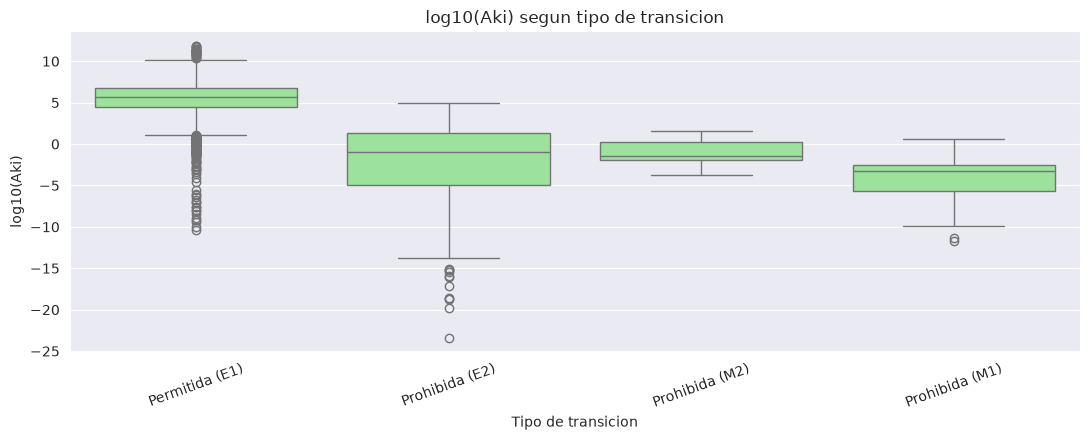

Si las transiciones prohibidas ocupan un rango de Aki claramente distinto,
entonces sus 'outliers' son FISICA LEGITIMA y no deben tratarse como error.


In [67]:
# El tipo de transicion explica buena parte de los atipicos de Aki: las transiciones
# prohibidas (M1, E2) tienen Aki muchos ordenes de magnitud menor que las permitidas.
if col_aki and COL_L["tipo"]:
    d = df_lines_num[[COL_L["tipo"], col_aki]].copy()
    d = d[d[col_aki] > 0]
    d["clase"] = np.where(d[COL_L["tipo"]].isna(), "Permitida (E1)", "Prohibida (" + d[COL_L["tipo"]].astype(str) + ")")
    d["log10_Aki"] = np.log10(d[col_aki])

    resumen = d.groupby("clase")["log10_Aki"].agg(["count", "min", "median", "max"]).round(2)
    display(resumen.sort_values("count", ascending=False))

    top_clases = d["clase"].value_counts().head(6).index
    plt.figure(figsize=(11, 4.5))
    sns.boxplot(data=d[d["clase"].isin(top_clases)], x="clase", y="log10_Aki", color="lightgreen")
    plt.title("log10(Aki) segun tipo de transicion")
    plt.xlabel("Tipo de transicion")
    plt.ylabel("log10(Aki)")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print("Si las transiciones prohibidas ocupan un rango de Aki claramente distinto,")
    print("entonces sus 'outliers' son FISICA LEGITIMA y no deben tratarse como error.")

---
# Sección 10 — Relaciones entre variables

Matriz de correlación y cruces categóricos. Se incluye `log10(Aki)` además de `Aki` crudo
porque la correlación de Pearson mide relación **lineal**: sobre una variable que abarca
nueve órdenes de magnitud, el coeficiente sobre el valor crudo está dominado por unos pocos
valores extremos y no describe la relación real.

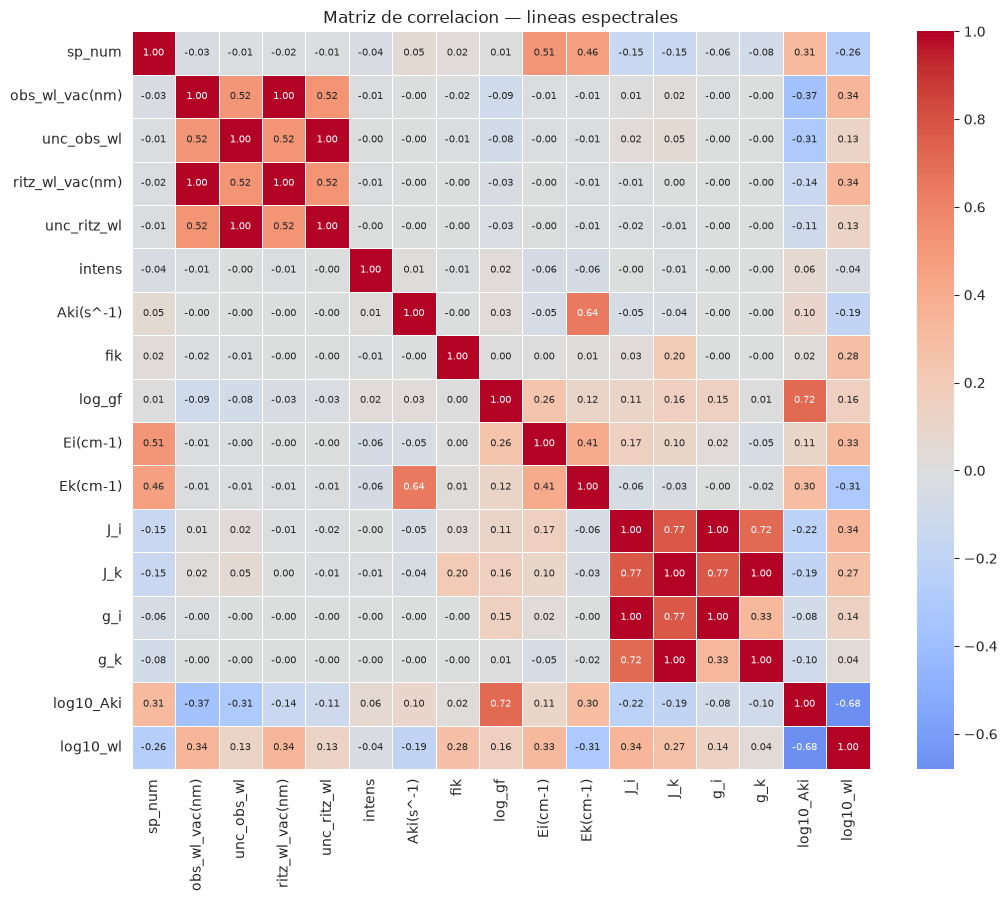

,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1),fik,log_gf,Ei(cm-1),Ek(cm-1),J_i,J_k,g_i,g_k,log10_Aki,log10_wl
sp_num,1.000,-0.034,-0.012,-0.022,-0.008,-0.036,0.050,0.023,0.008,0.515,0.464,-0.145,-0.146,-0.056,-0.077,0.314,-0.257
obs_wl_vac(nm),-0.034,1.000,0.519,1.000,0.524,-0.008,-0.002,-0.016,-0.094,-0.006,-0.011,0.006,0.020,-0.005,-0.003,-0.367,0.344
unc_obs_wl,-0.012,0.519,1.000,0.524,1.000,-0.001,-0.002,-0.014,-0.080,-0.005,-0.007,0.023,0.051,-0.001,-0.001,-0.310,0.125
ritz_wl_vac(nm),-0.022,1.000,0.524,1.000,0.522,-0.008,-0.001,-0.000,-0.031,-0.004,-0.009,-0.011,0.001,-0.003,-0.002,-0.143,0.345
unc_ritz_wl,-0.008,0.524,1.000,0.522,1.000,-0.001,-0.001,-0.000,-0.027,-0.003,-0.005,-0.018,-0.009,-0.001,-0.001,-0.106,0.125
intens,-0.036,-0.008,-0.001,-0.008,-0.001,1.000,0.010,-0.007,0.025,-0.063,-0.059,-0.001,-0.011,-0.003,-0.003,0.065,-0.036
Aki(s^-1),0.050,-0.002,-0.002,-0.001,-0.001,0.010,1.000,-0.001,0.026,-0.052,0.642,-0.049,-0.039,-0.004,-0.004,0.096,-0.188
fik,0.023,-0.016,-0.014,-0.000,-0.000,-0.007,-0.001,1.000,0.003,0.003,0.011,0.031,0.197,-0.001,-0.002,0.016,0.275
log_gf,0.008,-0.094,-0.080,-0.031,-0.027,0.025,0.026,0.003,1.000,0.258,0.117,0.113,0.159,0.148,0.008,0.715,0.157
Ei(cm-1),0.515,-0.006,-0.005,-0.004,-0.003,-0.063,-0.052,0.003,0.258,1.000,0.411,0.166,0.103,0.023,-0.051,0.106,0.326


In [68]:
d_corr = df_lines_num[NUM_L].copy()
if col_aki:
    positivos = d_corr[col_aki] > 0
    d_corr["log10_Aki"] = np.where(positivos, np.log10(d_corr[col_aki].where(positivos)), np.nan)
if col_wl:
    pos_wl = d_corr[col_wl] > 0
    d_corr["log10_wl"] = np.where(pos_wl, np.log10(d_corr[col_wl].where(pos_wl)), np.nan)

# Se descartan columnas sin varianza o casi vacias, que ensucian la matriz.
utiles = [c for c in d_corr.columns if d_corr[c].notna().sum() > 50 and d_corr[c].nunique() > 1]
matriz = d_corr[utiles].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, annot_kws={"size": 7})
plt.title("Matriz de correlacion — lineas espectrales")
plt.tight_layout()
plt.show()

display(matriz.round(3))

In [69]:
if col_aki and col_wl:
    sub = d_corr[[col_wl, col_aki, "log10_wl", "log10_Aki"]].dropna()
    print("Correlacion entre longitud de onda y Aki — la relacion central de la pregunta:")
    print(f"  Pearson sobre valores crudos        : {sub[col_wl].corr(sub[col_aki]):+.4f}")
    print(f"  Pearson sobre log10 de ambas        : {sub['log10_wl'].corr(sub['log10_Aki']):+.4f}")
    print(f"  Spearman (monotona, robusta a colas): {sub[col_wl].corr(sub[col_aki], method='spearman'):+.4f}")
    print()
    print(f"  Calculado sobre {len(sub):,} lineas que tienen ambas variables.")

Correlacion entre longitud de onda y Aki — la relacion central de la pregunta:
  Pearson sobre valores crudos        : -0.0023
  Pearson sobre log10 de ambas        : -0.6805
  Spearman (monotona, robusta a colas): -0.5862

  Calculado sobre 4,462 lineas que tienen ambas variables.


In [70]:
# Cruces categoricos, siguiendo el patron de crosstab del ejemplo de clase.
if COL_L["elemento"] and COL_L["tipo"]:
    clase_trans = np.where(df_lines[COL_L["tipo"]].isna(), "Permitida (E1)", "Prohibida")
    ct = pd.crosstab(df_lines_num[COL_L["elemento"]], clase_trans, margins=True)
    print("=== Elemento x tipo de transicion ===")
    display(ct)

=== Elemento x tipo de transicion ===


col_0,Permitida (E1),Prohibida,All
element,,,
B,927,36,963
Be,1251,11,1262
C,3689,18,3707
F,299,13,312
H,509,59,568
He,2258,42,2300
Li,966,41,1007
N,2045,73,2118
Ne,3502,9,3511


In [71]:
if COL_L["elemento"] and "region_espectral" in df_lines_num.columns:
    ct2 = pd.crosstab(df_lines_num[COL_L["elemento"]], df_lines_num["region_espectral"], margins=True)
    print("=== Elemento x region espectral ===")
    display(ct2)

    ct2_pct = pd.crosstab(df_lines_num[COL_L["elemento"]], df_lines_num["region_espectral"],
                          normalize="index") * 100
    print("=== Mismo cruce en % por elemento ===")
    display(ct2_pct.round(1))

=== Elemento x region espectral ===


region_espectral,Infrarrojo,Microondas/Radio,Rayos X,Ultravioleta,Visible,sin dato,All
element,,,,,,,
B,29,0,23,380,73,458,963
Be,98,0,63,637,196,268,1262
C,513,0,27,1127,689,1351,3707
F,78,0,0,94,109,31,312
H,71,48,0,75,20,354,568
He,64,0,0,57,42,2137,2300
Li,25,0,0,306,57,619,1007
N,64,0,0,98,96,1860,2118
Ne,1269,0,0,1259,901,82,3511


=== Mismo cruce en % por elemento ===


region_espectral,Infrarrojo,Microondas/Radio,Rayos X,Ultravioleta,Visible,sin dato
element,,,,,,
B,3.0,0.0,2.4,39.5,7.6,47.6
Be,7.8,0.0,5.0,50.5,15.5,21.2
C,13.8,0.0,0.7,30.4,18.6,36.4
F,25.0,0.0,0.0,30.1,34.9,9.9
H,12.5,8.5,0.0,13.2,3.5,62.3
He,2.8,0.0,0.0,2.5,1.8,92.9
Li,2.5,0.0,0.0,30.4,5.7,61.5
N,3.0,0.0,0.0,4.6,4.5,87.8
Ne,36.1,0.0,0.0,35.9,25.7,2.3


=== Cobertura de Aki por espectro (ordenado de peor a mejor) ===


,lineas_totales,con_Aki,%_con_Aki
espectro,,,
Ne II,1914,233,12.2
Be II,681,149,21.9
Ne I,1597,533,33.4
F II,150,67,44.7
O II,1630,876,53.7
Be I,581,394,67.8
B I,371,269,72.5
B II,592,435,73.5
F I,162,120,74.1


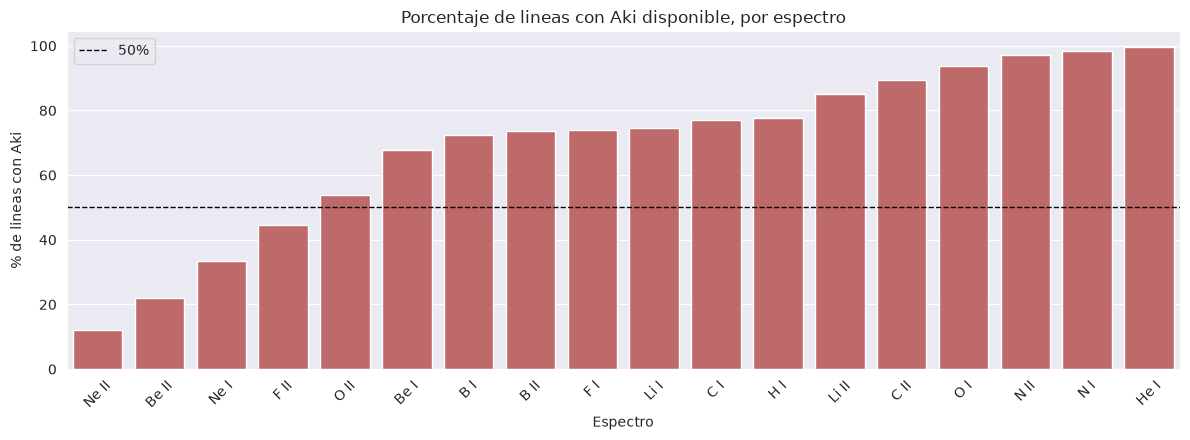

In [72]:
# Disponibilidad de Aki por espectro: cuantas lineas de cada elemento son realmente
# utilizables para responder la pregunta cientifica.
if col_aki and "espectro" in df_lines_num.columns:
    disp = df_lines_num.groupby("espectro").agg(
        lineas_totales=(col_aki, "size"),
        con_Aki=(col_aki, "count"),
    )
    disp["%_con_Aki"] = (disp["con_Aki"] / disp["lineas_totales"] * 100).round(1)
    disp = disp.sort_values("%_con_Aki")

    print("=== Cobertura de Aki por espectro (ordenado de peor a mejor) ===")
    display(disp)

    plt.figure(figsize=(12, 4.5))
    sns.barplot(x=disp.index, y=disp["%_con_Aki"], color="indianred")
    plt.axhline(50, linestyle="--", color="black", linewidth=1, label="50%")
    plt.title("Porcentaje de lineas con Aki disponible, por espectro")
    plt.xlabel("Espectro")
    plt.ylabel("% de lineas con Aki")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

---
# Sección 11 — Construcción de `df_analysis`: la unión de las dos fuentes

Esta es la sección donde se construye el **tercer dataset**. El plan del proyecto dejó
deliberadamente abierta la elección de la clave de unión, porque no se puede decidir sin ver
las columnas reales. Aquí no se elige una a ciegas: se **prueban varias estrategias y se
mide la cobertura de cada una**, y se adopta la mejor.

### Un detalle físico que cambia el diseño del merge

Cada línea espectral es un salto entre **dos** niveles: el inferior y el superior. Por lo
tanto la unión correcta no es un solo `merge`, sino **dos**: la tabla de niveles se une una
vez como nivel inferior (sufijo `_inf`) y otra vez como nivel superior (sufijo `_sup`). Así
cada fila de `df_analysis` describe la transición completa con las propiedades de sus dos
extremos.

### Y una advertencia sobre el modelo relacional

`df_analysis` es una **herramienta de diagnóstico de esta etapa, no el diseño final de la
base de datos**. Una tabla ancha repite los datos completos de los dos niveles en cada línea,
que es justamente la redundancia que el modelo relacional debe evitar. La regla es: **unir
para explorar, separar para modelar**. Los tres DataFrames se conservan por separado.

In [73]:
print("=== Columnas disponibles en cada fuente ===")
maxlen = max(len(df_lines.columns), len(df_levels.columns))
izq = list(df_lines.columns) + [""] * (maxlen - len(df_lines.columns))
der = list(df_levels.columns) + [""] * (maxlen - len(df_levels.columns))
display(pd.DataFrame({"LINEAS ESPECTRALES": izq, "NIVELES DE ENERGIA": der}))

=== Columnas disponibles en cada fuente ===


,LINEAS ESPECTRALES,NIVELES DE ENERGIA
0,element,espectro
1,sp_num,Configuration
2,obs_wl_vac(nm),Term
3,unc_obs_wl,J
4,ritz_wl_vac(nm),g
5,unc_ritz_wl,Prefix
6,intens,Level (eV)
7,Aki(s^-1),Suffix
8,fik,Uncertainty (eV)
9,log_gf,Leading percentages


In [74]:
# ---------------------------------------------------------------------------
# Estrategia A — union por identificador interno de nivel
# ---------------------------------------------------------------------------
tiene_ids_lineas = bool(COL_L["id_i"] and COL_L["id_k"])
tiene_ids_niveles = bool(COL_N["level_id"])

print("Estrategia A: union por Level ID")
print(f"  IDs de nivel en LINEAS  : {tiene_ids_lineas}  ({COL_L['id_i']}, {COL_L['id_k']})")
print(f"  IDs de nivel en NIVELES : {tiene_ids_niveles}  ({COL_N['level_id']})")
print()

cobertura_A = 0.0
if tiene_ids_lineas and tiene_ids_niveles:
    # Se toman del DataFrame DECODIFICADO, nunca de la vista numerica: un ID es un
    # codigo, y convertirlo a numero le borraria los ceros a la izquierda.
    id_inf = normalizar_texto(df_lines[COL_L["id_i"]])
    id_sup = normalizar_texto(df_lines[COL_L["id_k"]])
    id_niv = normalizar_texto(df_levels[COL_N["level_id"]])

    print("Formato de los identificadores (deben ser comparables entre fuentes):")
    print(f"  Ejemplo ID_i en lineas  : {id_inf.dropna().head(3).tolist()}")
    print(f"  Ejemplo Level ID niveles: {id_niv.dropna().head(3).tolist()}")
    print()

    universo_id = set(id_niv.dropna())
    hit_inf = id_inf.isin(universo_id)
    hit_sup = id_sup.isin(universo_id)
    cobertura_A = float((hit_inf & hit_sup).mean() * 100)

    print(f"  Identificadores unicos en la tabla de niveles: {len(universo_id):,}")
    print(f"  Lineas cuyo nivel INFERIOR tiene pareja: {int(hit_inf.sum()):,} "
          f"({hit_inf.mean() * 100:.2f}%)")
    print(f"  Lineas cuyo nivel SUPERIOR tiene pareja: {int(hit_sup.sum()):,} "
          f"({hit_sup.mean() * 100:.2f}%)")
    print(f"  Lineas con AMBOS niveles emparejados   : {int((hit_inf & hit_sup).sum()):,} "
          f"({cobertura_A:.2f}%)")
else:
    print("  -> NO VIABLE: al menos un endpoint no devolvio IDs de nivel.")

Estrategia A: union por Level ID
  IDs de nivel en LINEAS  : True  (ID_i, ID_k)
  IDs de nivel en NIVELES : True  (Level ID)

Formato de los identificadores (deben ser comparables entre fuentes):
  Ejemplo ID_i en lineas  : ['006002.000001', '006002.000002', '006002.000004']
  Ejemplo Level ID niveles: ['001001.001.000001', '001001.001.000002', '001001.001.000004']

  Identificadores unicos en la tabla de niveles: 5,752
  Lineas cuyo nivel INFERIOR tiene pareja: 18,073 (98.81%)
  Lineas cuyo nivel SUPERIOR tiene pareja: 18,073 (98.81%)
  Lineas con AMBOS niveles emparejados   : 18,073 (98.81%)


In [75]:
# ---------------------------------------------------------------------------
# Estrategia B — union por identidad cuantica (espectro + configuracion + termino + J)
# ---------------------------------------------------------------------------
# Se normaliza el texto en AMBOS lados antes de comparar: si un lado escribe '1s2.2s'
# y el otro '1s2.2s ', sin normalizar no emparejarian nunca.

def clave_nivel_desde_lineas(df, sufijo):
    # sufijo: 'i' para el nivel inferior, 'k' para el superior
    conf = COL_L[f"conf_{sufijo}"]
    term = COL_L[f"term_{sufijo}"]
    jota = COL_L[f"J_{sufijo}"]
    if not (conf and term and jota):
        return None
    return pd.DataFrame({
        "k_espectro": normalizar_texto(df["espectro"]),
        "k_conf": normalizar_texto(df[conf]),
        "k_term": normalizar_texto(df[term]),
        "k_J": normalizar_texto(df[jota]),
    })


def clave_nivel_desde_niveles(df):
    if not (COL_N["conf"] and COL_N["term"] and COL_N["J"]):
        return None
    return pd.DataFrame({
        "k_espectro": normalizar_texto(df[COL_N["espectro"]]),
        "k_conf": normalizar_texto(df[COL_N["conf"]]),
        "k_term": normalizar_texto(df[COL_N["term"]]),
        "k_J": normalizar_texto(df[COL_N["J"]]),
    })


# Tambien desde el decodificado: en la vista numerica, J_i = "1/2" se habria
# convertido en NaN y la clave quedaria incompleta en miles de filas.
claves_inf = clave_nivel_desde_lineas(df_lines, "i")
claves_sup = clave_nivel_desde_lineas(df_lines, "k")
claves_niv = clave_nivel_desde_niveles(df_levels)

CLAVE_B = ["k_espectro", "k_conf", "k_term", "k_J"]

if claves_inf is not None and claves_niv is not None:
    # Solo entran al universo los niveles con la clave COMPLETA: una clave con algun
    # componente ausente no identifica ningun nivel y no puede emparejar con nada.
    niv_completas = claves_niv[CLAVE_B].notna().all(axis=1)
    universo = set(map(tuple, claves_niv.loc[niv_completas, CLAVE_B].values))

    inf_completas = claves_inf[CLAVE_B].notna().all(axis=1)
    sup_completas = claves_sup[CLAVE_B].notna().all(axis=1)

    cob_inf = claves_inf[CLAVE_B].apply(tuple, axis=1).isin(universo) & inf_completas
    cob_sup = claves_sup[CLAVE_B].apply(tuple, axis=1).isin(universo) & sup_completas

    print(f"  Niveles con clave completa: {int(niv_completas.sum()):,} de {len(claves_niv):,}")
    print(f"  Lineas con clave inferior completa: {int(inf_completas.sum()):,} de {len(claves_inf):,}")

    print("Estrategia B: union por (espectro + configuracion + termino + J)")
    print(f"  Niveles unicos disponibles como universo: {len(universo):,}")
    print(f"  Lineas cuyo nivel INFERIOR encuentra pareja: {int(cob_inf.sum()):,} "
          f"({cob_inf.mean() * 100:.2f}%)")
    print(f"  Lineas cuyo nivel SUPERIOR encuentra pareja: {int(cob_sup.sum()):,} "
          f"({cob_sup.mean() * 100:.2f}%)")
    print(f"  Lineas con AMBOS niveles emparejados       : {int((cob_inf & cob_sup).sum()):,} "
          f"({(cob_inf & cob_sup).mean() * 100:.2f}%)")
    cobertura_B = float((cob_inf & cob_sup).mean() * 100)
else:
    cobertura_B = 0.0
    print("Estrategia B NO evaluable: faltan columnas de configuracion / termino / J.")

  Niveles con clave completa: 5,701 de 5,752
  Lineas con clave inferior completa: 17,855 de 18,290
Estrategia B: union por (espectro + configuracion + termino + J)
  Niveles unicos disponibles como universo: 5,685
  Lineas cuyo nivel INFERIOR encuentra pareja: 17,855 (97.62%)
  Lineas cuyo nivel SUPERIOR encuentra pareja: 17,783 (97.23%)
  Lineas con AMBOS niveles emparejados       : 17,783 (97.23%)


In [76]:
# ---------------------------------------------------------------------------
# Estrategia C — union por energia, tras unificar unidades
# ---------------------------------------------------------------------------
# Las lineas traen Ei/Ek en cm-1 (en_unit=0) y los niveles traen Level en eV (units=1).
# Factor de conversion CODATA: 1 eV = 8065.543937 cm-1

EV_A_CM1 = 8065.543937

cobertura_C = 0.0
if COL_N["nivel"] and COL_L["Ei"]:
    niveles_cm1 = df_levels_num[COL_N["nivel"]] * EV_A_CM1
    esp_niv = normalizar_texto(df_levels[COL_N["espectro"]])

    print(f"Conversion aplicada: 1 eV = {EV_A_CM1} cm-1")
    print(f"  Rango de niveles en eV  : {df_levels_num[COL_N['nivel']].min():,.4f} a "
          f"{df_levels_num[COL_N['nivel']].max():,.4f}")
    print(f"  Rango convertido a cm-1 : {niveles_cm1.min():,.2f} a {niveles_cm1.max():,.2f}")
    print(f"  Rango de Ei en lineas   : {df_lines_num[COL_L['Ei']].min():,.2f} a "
          f"{df_lines_num[COL_L['Ei']].max():,.2f}")
    print()
    print("Si los rangos son comparables, la conversion es correcta y la energia sirve")
    print("al menos como VALIDACION CRUZADA de la clave elegida.")
    print()

    # Cobertura con distintas tolerancias de redondeo.
    esp_lin = normalizar_texto(df_lines_num["espectro"])
    for decimales in [0, -1, -2]:
        universo_e = set(zip(esp_niv, niveles_cm1.round(decimales)))
        hit = pd.Series(list(zip(esp_lin, df_lines_num[COL_L["Ei"]].round(decimales)))).isin(universo_e)
        tol = 10 ** (-decimales)
        print(f"  Tolerancia ~{tol:>5} cm-1 -> nivel inferior emparejado en "
              f"{hit.mean() * 100:5.2f}% de las lineas")
        cobertura_C = max(cobertura_C, float(hit.mean() * 100))
else:
    print("Estrategia C NO evaluable: faltan columnas de energia.")

Conversion aplicada: 1 eV = 8065.543937 cm-1
  Rango de niveles en eV  : 0.0000 a 294.7700
  Rango convertido a cm-1 : 0.00 a 2,377,480.39
  Rango de Ei en lineas   : 0.00 a 1,077,320.00

Si los rangos son comparables, la conversion es correcta y la energia sirve
al menos como VALIDACION CRUZADA de la clave elegida.

  Tolerancia ~    1 cm-1 -> nivel inferior emparejado en 79.97% de las lineas
  Tolerancia ~   10 cm-1 -> nivel inferior emparejado en 80.36% de las lineas
  Tolerancia ~  100 cm-1 -> nivel inferior emparejado en 80.36% de las lineas


In [77]:
print("=" * 72)
print("COMPARACION DE ESTRATEGIAS DE UNION")
print("=" * 72)
resumen_estrategias = pd.DataFrame([
    {"estrategia": "A — Level IDs internos del NIST",
     "viable": bool(tiene_ids_lineas and tiene_ids_niveles),
     "cobertura_%": round(cobertura_A, 2)},
    {"estrategia": "B — espectro + configuracion + termino + J",
     "viable": cobertura_B > 0, "cobertura_%": round(cobertura_B, 2)},
    {"estrategia": "C — espectro + energia convertida (eV -> cm-1)",
     "viable": cobertura_C > 0, "cobertura_%": round(cobertura_C, 2)},
])
display(resumen_estrategias)

# Se adopta la de mayor cobertura. Ante empate se prefiere A, porque unir por un
# identificador univoco es conceptualmente superior a unir por texto reconstruido:
# no depende de como este escrita la configuracion ni de normalizaciones.
mejor = resumen_estrategias.sort_values("cobertura_%", ascending=False).iloc[0]
if cobertura_A >= max(cobertura_B, cobertura_C) and cobertura_A > 0:
    ESTRATEGIA = "A"
elif cobertura_B >= cobertura_C:
    ESTRATEGIA = "B"
else:
    ESTRATEGIA = "C"

print(f"\nESTRATEGIA ADOPTADA: {ESTRATEGIA}")

# Se construyen las claves definitivas segun la estrategia elegida.
if ESTRATEGIA == "A":
    CLAVE = ["k_id"]
    claves_inf_sel = pd.DataFrame({"k_id": id_inf})
    claves_sup_sel = pd.DataFrame({"k_id": id_sup})
    claves_niv_sel = pd.DataFrame({"k_id": id_niv})
    print("Clave: identificador interno de nivel del NIST (ID_i / ID_k <-> Level ID)")
else:
    CLAVE = CLAVE_B
    claves_inf_sel = claves_inf
    claves_sup_sel = claves_sup
    claves_niv_sel = claves_niv
    print(f"Clave: {CLAVE_B}")

COMPARACION DE ESTRATEGIAS DE UNION


,estrategia,viable,cobertura_%
0,A — Level IDs internos del NIST,True,98.81
1,B — espectro + configuracion + termino + J,True,97.23
2,C — espectro + energia convertida (eV -> cm-1),True,80.36



ESTRATEGIA ADOPTADA: A
Clave: identificador interno de nivel del NIST (ID_i / ID_k <-> Level ID)


### Unicidad de la clave: el riesgo de duplicar filas

Antes de unir hay que comprobar que la clave identifica **un solo** nivel dentro de cada
espectro. Si no lo hace, `merge` generaría una fila por cada coincidencia y el dataset de
líneas se inflaría artificialmente — un error silencioso que falsearía todos los conteos
posteriores.

In [78]:
niveles_con_clave = df_levels_num.copy()
for c in CLAVE:
    niveles_con_clave[c] = claves_niv_sel[c].values

# Un nivel sin clave no puede emparejarse con nada: se excluye del merge y se reporta.
sin_clave = niveles_con_clave[CLAVE].isna().any(axis=1)
print(f"Niveles totales                    : {len(niveles_con_clave):,}")
print(f"Niveles SIN clave utilizable       : {int(sin_clave.sum()):,}")

niveles_con_clave = niveles_con_clave[~sin_clave]

dups = int(niveles_con_clave.duplicated(subset=CLAVE).sum())
print(f"Claves unicas                      : {niveles_con_clave[CLAVE].drop_duplicates().shape[0]:,}")
print(f"Niveles con clave repetida         : {dups:,} "
      f"({dups / max(len(niveles_con_clave), 1) * 100:.2f}%)")

if dups > 0:
    print("\nEjemplo de claves repetidas:")
    m = niveles_con_clave.duplicated(subset=CLAVE, keep=False)
    cols_ej = CLAVE + [c for c in [COL_N["nivel"], COL_N["ref"]] if c]
    display(niveles_con_clave[m].sort_values(CLAVE)[cols_ej].head(8))
    print("\nDECISION: para el merge se conserva la PRIMERA aparicion de cada clave")
    print("(los niveles vienen ordenados por energia, asi que la primera es la de menor")
    print("energia). Esto evita inflar el dataset de lineas. Queda documentado como")
    print("limitacion de la union, NO como limpieza de los datos originales.")
else:
    print("\nLa clave es UNICA: el merge no puede duplicar filas.")

niveles_unicos = niveles_con_clave.drop_duplicates(subset=CLAVE, keep="first")
print(f"\nTabla de niveles lista para el merge: {len(niveles_unicos):,} filas")

Niveles totales                    : 5,752
Niveles SIN clave utilizable       : 0
Claves unicas                      : 5,752
Niveles con clave repetida         : 0 (0.00%)

La clave es UNICA: el merge no puede duplicar filas.

Tabla de niveles lista para el merge: 5,752 filas


In [79]:
# ---------------------------------------------------------------------------
# DOBLE MERGE: los niveles se unen dos veces, como inferior y como superior
# ---------------------------------------------------------------------------
COLS_NIVEL = [c for c in [COL_N["nivel"], COL_N["unc"], COL_N["g"],
                          COL_N["lande"], COL_N["perc"], COL_N["ref"], COL_N["level_id"]] if c]

base = df_lines_num.copy()
for c in CLAVE:
    base[c + "_inf"] = claves_inf_sel[c].values
    base[c + "_sup"] = claves_sup_sel[c].values

niv_inf = niveles_unicos[CLAVE + COLS_NIVEL].copy()
niv_inf.columns = [c + "_inf" for c in CLAVE] + [c + "_inf" for c in COLS_NIVEL]

niv_sup = niveles_unicos[CLAVE + COLS_NIVEL].copy()
niv_sup.columns = [c + "_sup" for c in CLAVE] + [c + "_sup" for c in COLS_NIVEL]

filas_antes = len(base)

df_analysis = base.merge(
    niv_inf, on=[c + "_inf" for c in CLAVE], how="left", indicator="match_inf"
)
df_analysis = df_analysis.merge(
    niv_sup, on=[c + "_sup" for c in CLAVE], how="left", indicator="match_sup"
)

print("=== Resultado del doble merge ===")
print(f"Filas en df_lines            : {filas_antes:,}")
print(f"Filas en df_analysis         : {len(df_analysis):,}")
print(f"Diferencia                   : {len(df_analysis) - filas_antes:+,}")
print(f"Columnas en df_analysis      : {df_analysis.shape[1]}")

=== Resultado del doble merge ===
Filas en df_lines            : 18,290
Filas en df_analysis         : 18,290
Diferencia                   : +0
Columnas en df_analysis      : 46


In [80]:
print("=== Verificacion de integridad del merge ===")

if len(df_analysis) == filas_antes:
    print("OK: el merge NO duplico filas. La clave era unica del lado de los niveles.")
else:
    print(f"ATENCION: el merge cambio el numero de filas en {len(df_analysis) - filas_antes:+,}.")
    print("La clave no era unica; revisar la celda de unicidad de arriba.")

print()
for lado, col in [("nivel INFERIOR", "match_inf"), ("nivel SUPERIOR", "match_sup")]:
    vc = df_analysis[col].value_counts()
    emparejadas = int(vc.get("both", 0))
    solas = int(vc.get("left_only", 0))
    print(f"{lado}:")
    print(f"   emparejado con la tabla de niveles: {emparejadas:,} ({emparejadas / len(df_analysis) * 100:.2f}%)")
    print(f"   sin pareja (left_only)            : {solas:,} ({solas / len(df_analysis) * 100:.2f}%)")

ambos = (df_analysis["match_inf"] == "both") & (df_analysis["match_sup"] == "both")
print()
print(f"Lineas con AMBOS niveles emparejados: {int(ambos.sum()):,} ({ambos.mean() * 100:.2f}%)")
print()
print("Las lineas sin pareja NO son un fallo del codigo: son un HALLAZGO de calidad de")
print("datos. Significan que el catalogo de lineas del NIST referencia niveles que su")
print("propio catalogo de niveles no documenta con la misma identidad cuantica.")

=== Verificacion de integridad del merge ===
OK: el merge NO duplico filas. La clave era unica del lado de los niveles.

nivel INFERIOR:
   emparejado con la tabla de niveles: 18,073 (98.81%)
   sin pareja (left_only)            : 217 (1.19%)
nivel SUPERIOR:
   emparejado con la tabla de niveles: 18,073 (98.81%)
   sin pareja (left_only)            : 217 (1.19%)

Lineas con AMBOS niveles emparejados: 18,073 (98.81%)

Las lineas sin pareja NO son un fallo del codigo: son un HALLAZGO de calidad de
datos. Significan que el catalogo de lineas del NIST referencia niveles que su
propio catalogo de niveles no documenta con la misma identidad cuantica.


In [81]:
# Validacion cruzada: la energia del nivel emparejado deberia coincidir con la energia
# que la propia linea declara. Es la mejor prueba de que el merge unio lo correcto.
if COL_N["nivel"] and COL_L["Ei"]:
    col_niv_inf = COL_N["nivel"] + "_inf"
    comparables = df_analysis[col_niv_inf].notna() & df_analysis[COL_L["Ei"]].notna()

    e_desde_niveles = df_analysis.loc[comparables, col_niv_inf] * EV_A_CM1
    e_desde_lineas = df_analysis.loc[comparables, COL_L["Ei"]]
    diferencia = (e_desde_niveles - e_desde_lineas).abs()

    print(f"Filas comparables: {int(comparables.sum()):,}")
    print("\nDiferencia |E(niveles, convertida) - Ei(lineas)| en cm-1:")
    display(diferencia.describe().to_frame("cm-1"))

    for tol in [1, 10, 100]:
        pct = (diferencia < tol).mean() * 100
        print(f"  Coinciden dentro de {tol:>4} cm-1: {pct:6.2f}% de las filas comparables")
    print()
    print("Un porcentaje alto confirma que el merge emparejo los niveles CORRECTOS")
    print("y valida de paso la conversion de unidades entre las dos fuentes.")

Filas comparables: 14,634

Diferencia |E(niveles, convertida) - Ei(lineas)| en cm-1:


,cm-1
count,14634.000000
mean,0.006872
std,0.097109
min,0.000000
25%,0.000013
50%,0.000136
75%,0.000988
max,2.769209


  Coinciden dentro de    1 cm-1:  99.66% de las filas comparables
  Coinciden dentro de   10 cm-1: 100.00% de las filas comparables
  Coinciden dentro de  100 cm-1: 100.00% de las filas comparables

Un porcentaje alto confirma que el merge emparejo los niveles CORRECTOS
y valida de paso la conversion de unidades entre las dos fuentes.


In [82]:
print("=== Vista de df_analysis ===")
print(f"Dimensiones: {df_analysis.shape}")
display(df_analysis.head())

=== Vista de df_analysis ===
Dimensiones: (18290, 46)


,element,sp_num,obs_wl_vac(nm),unc_obs_wl,ritz_wl_vac(nm),unc_ritz_wl,intens,Aki(s^-1),fik,log_gf,Acc,Ei(cm-1),Ek(cm-1),conf_i,term_i,J_i,conf_k,term_k,J_k,g_i,g_k,Type,tp_ref,line_ref,ID_i,ID_k,espectro,region_espectral,k_id_inf,k_id_sup,Level (eV)_inf,Uncertainty (eV)_inf,g_inf,Lande_inf,Leading percentages_inf,Reference_inf,Level ID_inf,match_inf,Level (eV)_sup,Uncertainty (eV)_sup,g_sup,Lande_sup,Leading percentages_sup,Reference_sup,Level ID_sup,match_sup
0,C,2.0,4.2767,0.0004,4.2766,0.0004,NaN,9.000000e+10,0.023,-1.33,D+,0.00000,2338290.0,2s2.2p,2P*,NaN,1s.2s2.2p2,2S,NaN,2.0,2.0,NaN,T9848LS,L20274,006002.000001,006002.000359,C II,Rayos X,006002.000001,006002.000359,0.00000,0.000000e+00,2.0,0.66576(6),96 : 3 2p3 2P*,"L22145,L6720",006002.000001,both,289.91,0.03,2.0,NaN,93 : 7 1s.2p4 2S,L22145,006002.000359,both
1,C,2.0,4.2767,0.0004,4.2767,0.0004,NaN,1.700000e+11,0.023,-1.03,D+,63.39509,2338290.0,2s2.2p,2P*,NaN,1s.2s2.2p2,2S,NaN,4.0,2.0,NaN,T9848LS,L20274,006002.000002,006002.000359,C II,Rayos X,006002.000002,006002.000359,0.00786,3.000000e-09,4.0,1.33412(6),96 : 3 2p3 2P*,"L22145,L6720",006002.000002,both,289.91,0.03,2.0,NaN,93 : 7 1s.2p4 2S,L22145,006002.000359,both
2,C,2.0,4.2836,0.0004,4.2836,0.0004,NaN,6.000000e+10,0.023,-1.00,E,43024.90000,2377500.0,2s.2p2,4P,NaN,1s.2s.(3S). 2p3.(2P*),4P*,NaN,4.0,6.0,NaN,T9848LS,L20274,006002.000004,006002.000367,C II,Rayos X,006002.000004,006002.000367,5.33441,4.000000e-05,4.0,(1.7349),99,"L22145,L15072",006002.000004,both,294.77,0.03,6.0,NaN,100,L22145,006002.000367,both
3,C,2.0,4.2836,0.0004,4.2836,0.0004,NaN,2.500000e+10,0.007,-1.60,E,43024.90000,2377500.0,2s.2p2,4P,NaN,1s.2s.(3S). 2p3.(2P*),4P*,NaN,4.0,4.0,NaN,T9848LS,L20274,006002.000004,006002.000366,C II,Rayos X,006002.000004,006002.000366,5.33441,4.000000e-05,4.0,(1.7349),99,"L22145,L15072",006002.000004,both,294.77,0.03,4.0,NaN,100,L22145,006002.000366,both
4,C,2.0,4.2836,0.0004,4.2836,0.0004,NaN,1.500000e+11,0.021,-1.10,E,43024.90000,2377500.0,2s.2p2,4P,NaN,1s.2s.(3S). 2p3.(2P*),4P*,NaN,4.0,2.0,NaN,T9848LS,L20274,006002.000004,006002.000365,C II,Rayos X,006002.000004,006002.000365,5.33441,4.000000e-05,4.0,(1.7349),99,"L22145,L15072",006002.000004,both,294.77,0.03,2.0,NaN,100,L22145,006002.000365,both


In [83]:
# Las columnas que aporto la union y que NO existian en el dataset de lineas.
nuevas = [c for c in df_analysis.columns if c not in df_lines_num.columns]
print(f"Columnas aportadas por la union: {len(nuevas)}")
for c in nuevas:
    if c.startswith("k_") or c.startswith("match_"):
        continue
    llenas = int(df_analysis[c].notna().sum())
    print(f"  {c:<40} {llenas:>8,} valores ({llenas / len(df_analysis) * 100:5.1f}%)")

Columnas aportadas por la union: 18
  Level (eV)_inf                             18,073 valores ( 98.8%)
  Uncertainty (eV)_inf                       13,441 valores ( 73.5%)
  g_inf                                      18,073 valores ( 98.8%)
  Lande_inf                                   1,136 valores (  6.2%)
  Leading percentages_inf                     7,796 valores ( 42.6%)
  Reference_inf                              13,097 valores ( 71.6%)
  Level ID_inf                               18,073 valores ( 98.8%)
  Level (eV)_sup                             18,073 valores ( 98.8%)
  Uncertainty (eV)_sup                       13,235 valores ( 72.4%)
  g_sup                                      18,073 valores ( 98.8%)
  Lande_sup                                     118 valores (  0.6%)
  Leading percentages_sup                     7,652 valores ( 41.8%)
  Reference_sup                              12,912 valores ( 70.6%)
  Level ID_sup                               18,073 valores ( 98.8%

In [84]:
# Re-chequeo: la union no debe haber distorsionado las distribuciones originales.
comparacion = []
for col in [c for c in [col_wl, col_aki, COL_L["Ei"], COL_L["Ek"]] if c]:
    a = df_lines_num[col].dropna()
    b = df_analysis[col].dropna()
    comparacion.append({
        "variable": col,
        "n_antes": len(a), "n_despues": len(b),
        "media_antes": a.mean(), "media_despues": b.mean(),
        "mediana_antes": a.median(), "mediana_despues": b.median(),
        "identicas": bool(len(a) == len(b) and np.isclose(a.mean(), b.mean())),
    })

print("=== Las distribuciones originales se conservan tras el merge? ===")
display(pd.DataFrame(comparacion))

=== Las distribuciones originales se conservan tras el merge? ===


,variable,n_antes,n_despues,media_antes,media_despues,mediana_antes,mediana_despues,identicas
0,obs_wl_vac(nm),9864,9864,3.422365e+07,3.422365e+07,399.7136,399.7136,True
1,Aki(s^-1),12603,12603,4.846888e+08,4.846888e+08,446000.0000,446000.0000,True
2,Ei(cm-1),14634,14634,1.300602e+05,1.300602e+05,107965.0568,107965.0568,True
3,Ek(cm-1),14117,14117,1.845056e+05,1.845056e+05,169839.4581,169839.4581,True


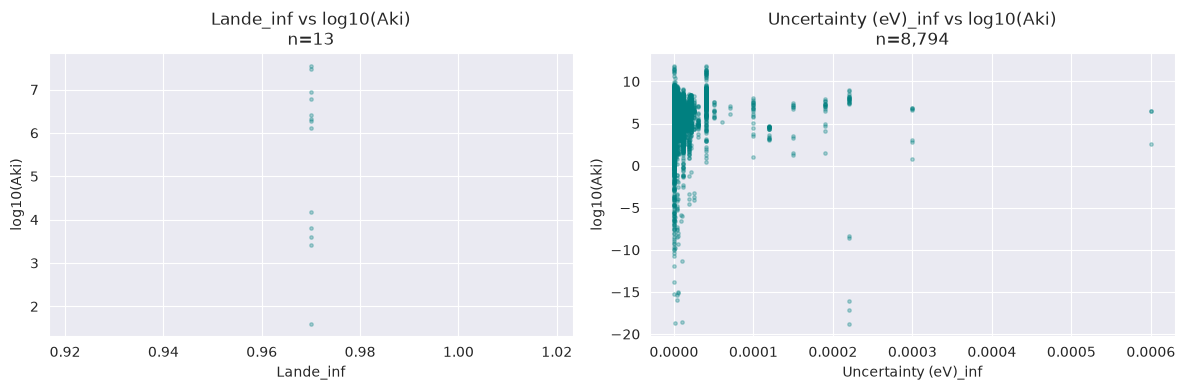

Estos cruces solo son posibles GRACIAS a la union: relacionan una propiedad
de la LINEA (Aki) con una propiedad del NIVEL que el archivo de lineas no trae.


In [85]:
# Que gano df_analysis frente a df_lines: variables de nivel que antes no existian.
col_lande_inf = (COL_N["lande"] + "_inf") if COL_N["lande"] else None
col_unc_inf = (COL_N["unc"] + "_inf") if COL_N["unc"] else None

extras = [c for c in [col_lande_inf, col_unc_inf] if c and c in df_analysis.columns]

if extras and col_aki:
    d = df_analysis[[col_aki] + extras].copy()
    for c in extras:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d = d[d[col_aki] > 0]
    d["log10_Aki"] = np.log10(d[col_aki])

    fig, axes = plt.subplots(1, len(extras), figsize=(6 * len(extras), 4))
    if len(extras) == 1:
        axes = [axes]
    for ax, c in zip(axes, extras):
        sub = d[[c, "log10_Aki"]].dropna()
        ax.scatter(sub[c], sub["log10_Aki"], s=6, alpha=0.3, color="teal")
        ax.set_xlabel(c)
        ax.set_ylabel("log10(Aki)")
        ax.set_title(f"{c} vs log10(Aki)\nn={len(sub):,}")
    plt.tight_layout()
    plt.show()

    print("Estos cruces solo son posibles GRACIAS a la union: relacionan una propiedad")
    print("de la LINEA (Aki) con una propiedad del NIVEL que el archivo de lineas no trae.")

In [86]:
print("=== Valores faltantes en df_analysis (top 25) ===")
falt_an = tabla_faltantes(df_analysis, "df_analysis")
display(falt_an.head(25))

=== Valores faltantes en df_analysis (top 25) ===
=== Valores faltantes: df_analysis (18,290 filas) ===


,total datos faltantes,porcentaje de datos faltante
Lande_sup,18172,99.35
Type,17955,98.17
Lande_inf,17154,93.79
intens,12178,66.58
Leading percentages_sup,10638,58.16
unc_obs_wl,10600,57.96
Leading percentages_inf,10494,57.38
J_k,8820,48.22
J_i,8732,47.74
obs_wl_vac(nm),8426,46.07


---
# Sección 12 — Diagnóstico consolidado

Resumen de todo lo encontrado. Este bloque es el **insumo directo** de la limpieza
(`notebooks/03_limpieza_datos.ipynb` / `docs/03_limpieza_datos.md`): cada decisión L1–L14
debe poder rastrearse hasta una cifra de esta sección.

In [87]:
print("=" * 78)
print("DIAGNOSTICO CONSOLIDADO — EXPLORACION DE DATOS NIST ASD")
print(f"Generado el {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 78)

print("\n1. VOLUMEN DE DATOS")
print("-" * 78)
print(f"  Lineas espectrales : {df_lines.shape[0]:>8,} filas x {df_lines.shape[1]:>3} columnas")
print(f"  Niveles de energia : {df_levels.shape[0]:>8,} filas x {df_levels.shape[1]:>3} columnas")
print(f"  df_analysis (union): {df_analysis.shape[0]:>8,} filas x {df_analysis.shape[1]:>3} columnas")
print(f"  Espectros cubiertos: {df_levels['espectro'].nunique()} de {len(ESPECTRA_LISTA)} solicitados")

print("\n2. COMPLETITUD (% de celdas vacias)")
print("-" * 78)
for nombre, df in [("Lineas", df_lines), ("Niveles", df_levels), ("df_analysis", df_analysis)]:
    celdas = int(np.prod(df.shape))
    vacias = int(df.isna().sum().sum())
    print(f"  {nombre:<12}: {vacias / celdas * 100:6.2f}%  ({vacias:,} de {celdas:,} celdas)")

print("\n3. COLUMNAS CRITICAS Y SU COBERTURA (sobre lineas espectrales)")
print("-" * 78)
for etiqueta, clave in [("Long. onda observada", "wl_obs"), ("Long. onda Ritz", "wl_ritz"),
                        ("Aki", "aki"), ("Energia inferior Ei", "Ei"), ("Energia superior Ek", "Ek")]:
    c = COL_L[clave]
    if c:
        n = int(df_lines_num[c].notna().sum())
        print(f"  {etiqueta:<22}: {n:>8,} valores ({n / len(df_lines_num) * 100:5.1f}%)")

print("\n4. PROBLEMAS DE TIPO DE DATO")
print("-" * 78)
prob_l = tipos_lines[tipos_lines["veredicto"].isin(
    ["numerica pura", "numerica con texto intercalado"])]
prob_n = tipos_levels[tipos_levels["veredicto"].isin(
    ["numerica pura", "numerica con texto intercalado"])]
print(f"  Columnas mal tipadas en lineas : {len(prob_l)}  -> {list(prob_l['columna'])}")
print(f"  Columnas mal tipadas en niveles: {len(prob_n)}  -> {list(prob_n['columna'])}")
print(f"  Valores perdidos al convertir (lineas) : {total_perdidos(rep_lines):,}")
print(f"  Valores perdidos al convertir (niveles): {total_perdidos(rep_levels):,}")

print("\n5. DUPLICADOS")
print("-" * 78)
print(f"  Filas exactamente duplicadas (lineas) : {int(df_lines.duplicated().sum()):,}")
print(f"  Filas exactamente duplicadas (niveles): {int(df_levels.duplicated().sum()):,}")
print(f"  Transiciones fisicamente repetidas    : {n_sub:,}")
print(f"  Niveles con identidad cuantica repetida: {n_sub_n:,}")

print("\n6. VALIDACION FISICA")
print("-" * 78)
for v in validaciones:
    marca = "OK   " if v["violaciones"] == 0 else "FALLA"
    print(f"  [{marca}] {v['validacion']:<55} {v['violaciones']:>6,}")

print("\n7. VALORES ATIPICOS (IQR) — principales variables")
print("-" * 78)
for _, f in iqr_lines.head(6).iterrows():
    print(f"  {str(f['columna'])[:34]:<34} {f['outliers']:>7,} outliers "
          f"({f['%_outliers']:>5.2f}%)  skew={f['skew']:>8.2f}")

print("\n8. UNION DE LAS DOS FUENTES")
print("-" * 78)
print(f"  Estrategia adoptada          : {ESTRATEGIA}")
print(f"  Clave utilizada              : {CLAVE}")
print(f"  Nivel inferior emparejado    : {(df_analysis['match_inf'] == 'both').mean() * 100:.2f}%")
print(f"  Nivel superior emparejado    : {(df_analysis['match_sup'] == 'both').mean() * 100:.2f}%")
print(f"  Ambos niveles emparejados    : {ambos.mean() * 100:.2f}%")
print(f"  Filas duplicadas por el merge: {len(df_analysis) - filas_antes:+,}")

print("\n9. UTILIDAD PARA LA PREGUNTA CIENTIFICA")
print("-" * 78)
if col_wl and col_aki:
    utiles_pregunta = df_lines_num[[col_wl, col_aki]].dropna()
    utiles_pregunta = utiles_pregunta[(utiles_pregunta[col_wl] > 0) & (utiles_pregunta[col_aki] > 0)]
    print(f"  Lineas con longitud de onda Y Aki: {len(utiles_pregunta):,} "
          f"({len(utiles_pregunta) / len(df_lines_num) * 100:.1f}% del total)")
    print(f"  Esta es la base real de evidencia disponible para responder la pregunta.")

print("\n" + "=" * 78)

DIAGNOSTICO CONSOLIDADO — EXPLORACION DE DATOS NIST ASD
Generado el 2026-09-19 19:06:19

1. VOLUMEN DE DATOS
------------------------------------------------------------------------------
  Lineas espectrales :   18,290 filas x  27 columnas
  Niveles de energia :    5,752 filas x  13 columnas
  df_analysis (union):   18,290 filas x  46 columnas
  Espectros cubiertos: 18 de 18 solicitados

2. COMPLETITUD (% de celdas vacias)
------------------------------------------------------------------------------
  Lineas      :  18.26%  (90,151 de 493,830 celdas)
  Niveles     :  30.78%  (23,013 de 74,776 celdas)
  df_analysis :  23.40%  (196,836 de 841,340 celdas)

3. COLUMNAS CRITICAS Y SU COBERTURA (sobre lineas espectrales)
------------------------------------------------------------------------------
  Long. onda observada  :    9,864 valores ( 53.9%)
  Long. onda Ritz       :   17,892 valores ( 97.8%)
  Aki                   :   12,603 valores ( 68.9%)
  Energia inferior Ei   :   14,634 val

---
## Conclusión de esta etapa y siguiente paso

Este notebook deja tres productos:

1. Los **archivos originales sin modificar** en `datos_originales/`, que son la evidencia de
   la fuente oficial.
2. Un **diagnóstico completo** de ambas fuentes: tipos, faltantes, duplicados, violaciones
   físicas, distribuciones, rangos, atípicos y correlaciones.
3. El **tercer dataset `df_analysis`**, construido con una clave de unión elegida por
   evidencia empírica y validada cruzando las energías de las dos fuentes.

**No se limpió ningún dato aquí.** Ese era el objetivo: diagnosticar primero, decidir
después, con criterio y no por reflejo.

El siguiente paso es **`notebooks/03_limpieza_datos.ipynb`** (documentado en
`docs/03_limpieza_datos.md`), que toma cada hallazgo de la Sección 12 y aplica —con
justificación— las decisiones L1–L14: qué columnas descartar, por qué **no** imputar Aki,
qué atípicos conservar por ser física legítima, y en qué orden ejecutar todo. Tras la
limpieza sigue el pipeline ETL y el modelo relacional en MySQL.